In [152]:
import os
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

load_dotenv()

DATABASE = os.getenv("DATABASE")
USER_DB  = os.getenv("USER_DB")
PASSWORD = os.getenv("PASSWORD")
HOST     = os.getenv("HOST")
PORT     = os.getenv("PORT")

url = URL.create(
    drivername="postgresql+psycopg2",
    username=USER_DB,
    password=PASSWORD,
    host=HOST,
    port=PORT,
    database=DATABASE,
)

db = create_engine(url)

In [153]:
query_string = """
SELECT d.*, s.date, s.price
FROM eda.king_county_house_details d
JOIN (
    SELECT DISTINCT ON (house_id) house_id, date, price
    FROM eda.king_county_house_sales
    ORDER BY house_id, date DESC
) s ON d.id = s.house_id
"""

df = pd.read_sql(query_string, db)
df.shape   # should show (21420, ...)

(21420, 21)

In [154]:
df.to_csv("data/kc_house_data.csv", index=False)

In [155]:
# 1. Overall price picture
df["price"].describe()

count    2.142000e+04
mean     5.418614e+05
std      3.675569e+05
min      7.800000e+04
25%      3.249500e+05
50%      4.505500e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

In [156]:
# 2. Which zipcodes are the most expensive ("rich" neighborhoods) and how many houses are in each
zip_stats = df.groupby("zipcode")["price"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)
zip_stats.head(15)

,mean,median,count
zipcode,,,
98039,2.187551e+06,1910000.0,49
98004,1.355972e+06,1150000.0,315
98040,1.194874e+06,993750.0,282
98112,1.096934e+06,917500.0,268
98102,8.996077e+05,710000.0,104
98109,8.800778e+05,736000.0,109
98105,8.632289e+05,675000.0,229
98006,8.581498e+05,760184.5,490
98119,8.497148e+05,744975.0,184


In [157]:
# 3. Waterfront price premium
df.groupby("waterfront")["price"].agg(["mean", "median", "count"])

,mean,median,count
waterfront,,,
0.0,5.341192e+05,450000.0,18914
1.0,1.717215e+06,1510000.0,146


In [158]:
# 4. Grade / condition vs price
df.groupby("grade")["price"].mean()
df.groupby("condition")["price"].mean()

condition
1    349480.357143
2    334005.487654
3    543939.561223
4    522310.528974
5    613289.410788
Name: price, dtype: float64

In [159]:
# 5. Renovated vs not-renovated price difference
df["is_renovated"] = df["yr_renovated"].apply(lambda x: 0 if x == 0 else 1)
df.groupby("is_renovated")["price"].mean()

is_renovated
0    532248.478155
1    577493.344979
Name: price, dtype: float64

In [160]:
# 6. Sale timing — is there a "best month" to sell?
df["date"] = pd.to_datetime(df["date"])
df["sale_month"] = df["date"].dt.month
df.groupby("sale_month")["price"].mean()

sale_month
1     527490.298047
2     508947.491158
3     544057.683200
4     562215.615074
5     551732.096532
6     558833.807531
7     547008.847279
8     539822.591218
9     533712.206640
10    541980.481122
11    523841.335244
12    526173.769547
Name: price, dtype: float64

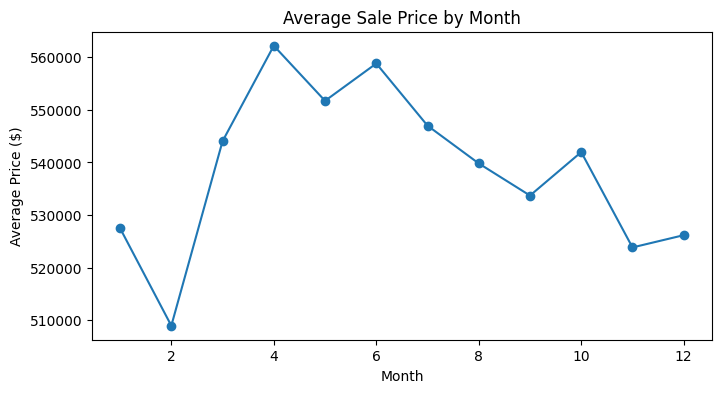

In [161]:
import matplotlib.pyplot as plt

df.groupby("sale_month")["price"].mean().plot(kind="line", marker="o", figsize=(8,4))
plt.title("Average Sale Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Price ($)")
plt.show()

In [162]:
df.columns
df["date"].dtype

dtype('<M8[s]')

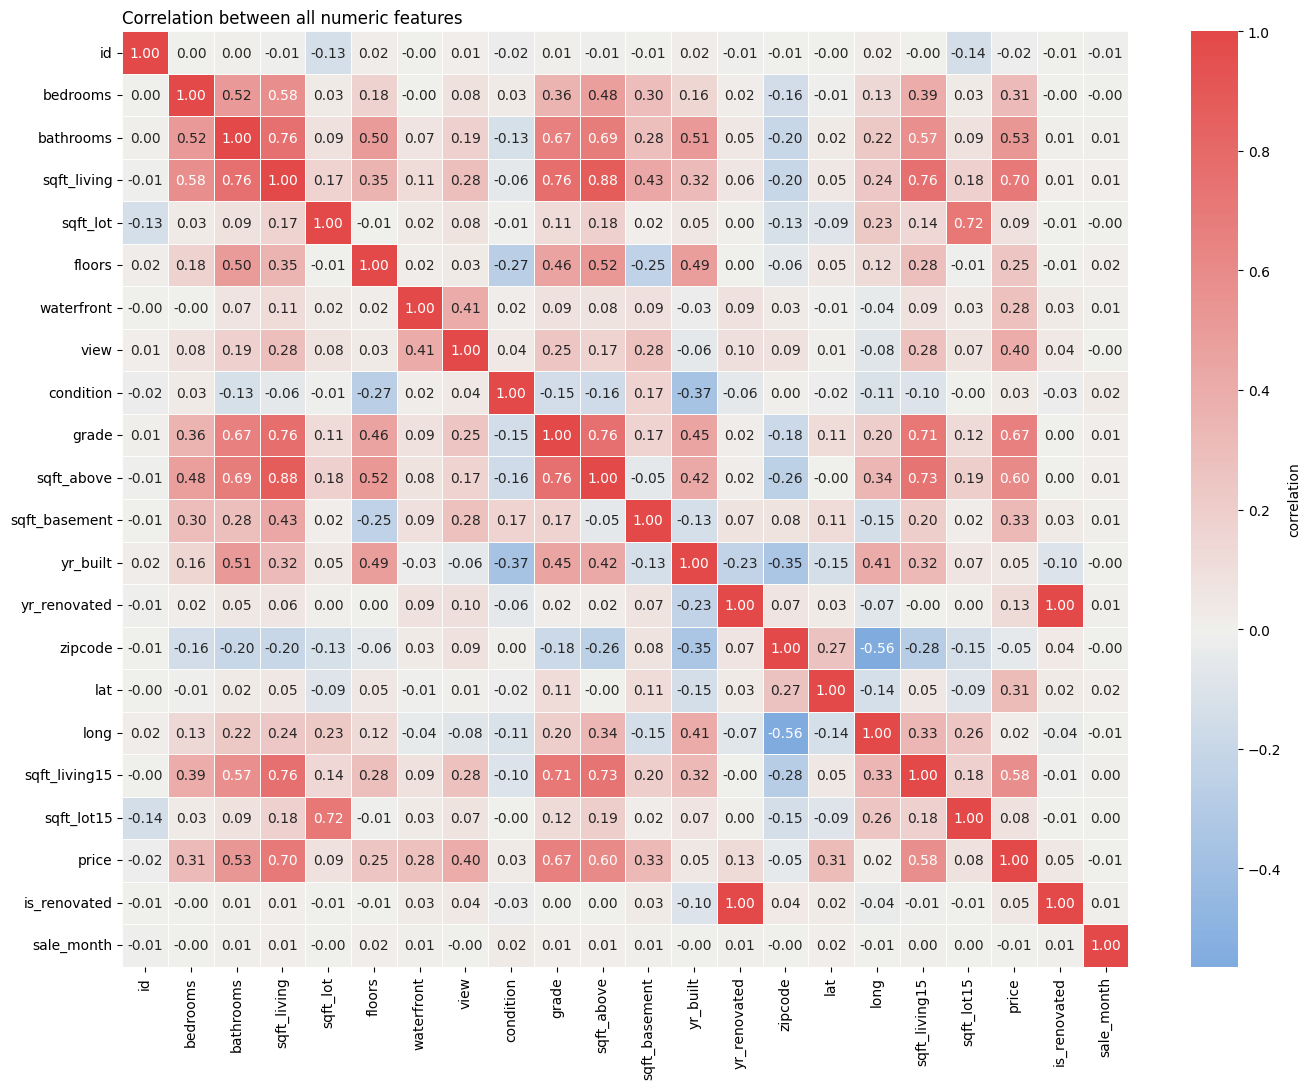

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

numeric_cols = df.select_dtypes(include="number").columns
corr = df[numeric_cols].corr()

# diverging blue <-> red, gray at zero (no correlation)
cmap = LinearSegmentedColormap.from_list(
    "diverging", ["#2a78d6", "#f0efec", "#e34948"]
)

plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=cmap, center=0,
            linewidths=0.5, linecolor="#fcfcfb",
            cbar_kws={"label": "correlation"})
plt.title("Correlation between all numeric features", loc="left")
plt.tight_layout()
plt.savefig("data/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

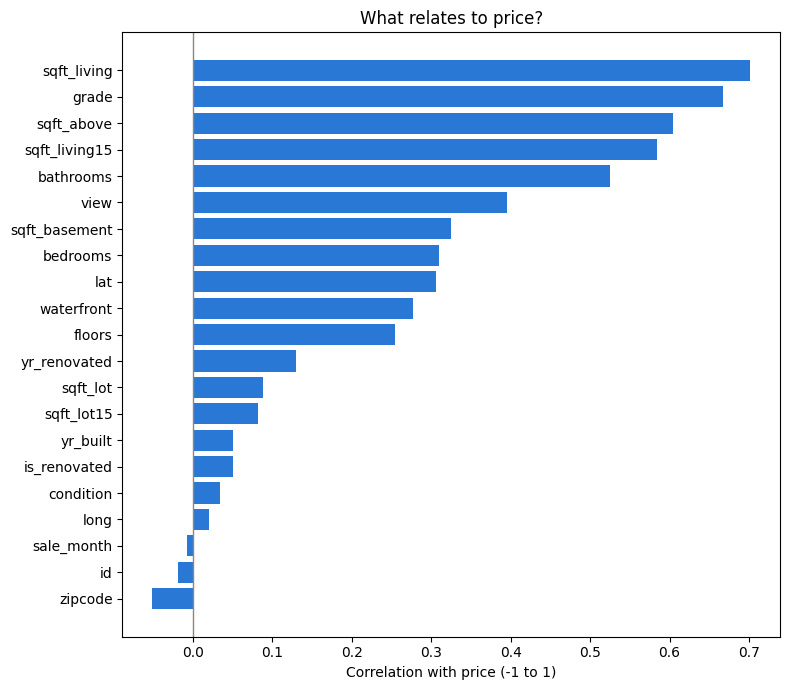

In [164]:
import matplotlib.pyplot as plt

corr_with_price = df.select_dtypes(include="number").corr()["price"].drop("price").sort_values()

plt.figure(figsize=(8, 7))
plt.barh(corr_with_price.index, corr_with_price.values, color="#2a78d6")
plt.axvline(0, color="#898781", linewidth=1)
plt.title("What relates to price?")
plt.xlabel("Correlation with price (-1 to 1)")
plt.tight_layout()
plt.show()

In [165]:
df

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,is_renovated,sale_month
0,1000102,6.0,3.00,2400.0,9373.0,2.0,NaN,0.0,3,7,...,0.0,98002,47.3262,-122.214,2060.0,7316.0,2015-04-22,300000.0,0,4
1,100100050,3.0,1.00,1320.0,11090.0,1.0,0.0,0.0,3,7,...,0.0,98155,47.7748,-122.304,1320.0,8319.0,2014-11-12,275000.0,0,11
2,1001200035,3.0,1.00,1350.0,7973.0,1.5,NaN,0.0,3,7,...,0.0,98188,47.4323,-122.292,1310.0,7491.0,2015-03-06,272450.0,0,3
3,1001200050,4.0,1.50,1260.0,7248.0,1.5,NaN,0.0,5,7,...,NaN,98188,47.4330,-122.292,1300.0,7732.0,2014-09-23,259000.0,1,9
4,1003000175,3.0,1.00,980.0,7606.0,1.0,0.0,0.0,3,7,...,0.0,98188,47.4356,-122.290,980.0,8125.0,2014-12-22,221000.0,0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21415,993002177,3.0,2.50,1380.0,1547.0,3.0,0.0,0.0,3,8,...,NaN,98103,47.6908,-122.341,1380.0,1465.0,2015-05-06,345000.0,1,5
21416,993002225,3.0,2.25,1520.0,1245.0,3.0,NaN,0.0,3,8,...,0.0,98103,47.6907,-122.340,1520.0,1470.0,2014-06-23,405000.0,0,6
21417,993002247,3.0,2.25,1550.0,1469.0,3.0,0.0,0.0,3,8,...,0.0,98103,47.6911,-122.341,1520.0,1465.0,2014-07-16,430000.0,0,7
21418,993002325,2.0,1.50,950.0,4625.0,1.0,0.0,0.0,4,7,...,NaN,98103,47.6912,-122.340,1440.0,4625.0,2014-06-23,430000.0,1,6


In [166]:
df["grade"].value_counts().sort_index()

grade
3        1
4       27
5      234
6     1995
7     8889
8     6041
9     2606
10    1130
11     396
12      88
13      13
Name: count, dtype: int64

In [167]:
GRADE_CUTOFF = 10

jennifer_segment = df[(df["waterfront"] == 1) & (df["grade"] >= GRADE_CUTOFF)]
print("Matching houses:", jennifer_segment.shape[0])
jennifer_segment[["price", "zipcode", "grade", "is_renovated"]].describe(include="all")

Matching houses: 57


,price,zipcode,grade,is_renovated
count,5.700000e+01,57.000000,57.000000,57.000000
mean,2.687719e+06,98073.245614,10.684211,0.280702
std,1.133780e+06,56.300939,0.759650,0.453336
min,3.800000e+05,98004.000000,10.000000,0.000000
25%,1.880000e+06,98033.000000,10.000000,0.000000
50%,2.510000e+06,98056.000000,11.000000,0.000000
75%,3.280000e+06,98116.000000,11.000000,1.000000
max,7.060000e+06,98199.000000,12.000000,1.000000


In [168]:
jennifer_segment.sort_values("price").head(3)

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,is_renovated,sale_month
16261,7631800110,3.0,2.50,1980.0,17342.0,2.0,1.0,4.0,3,10,...,0.0,98166,47.4551,-122.373,2060.0,17313.0,2014-09-18,380000.0,0,9
19392,8917100020,3.0,1.50,2170.0,16600.0,1.0,1.0,2.0,3,10,...,0.0,98052,47.6307,-122.088,3130.0,13875.0,2014-06-06,1150000.0,0,6
7608,3342104046,4.0,2.25,2890.0,18226.0,3.0,1.0,4.0,3,10,...,0.0,98056,47.5169,-122.209,2870.0,11151.0,2014-07-08,1570000.0,0,7


In [169]:
jennifer_segment["zipcode"].value_counts()

zipcode
98040    8
98008    7
98166    5
98075    4
98074    3
98056    3
98155    3
98105    3
98033    2
98052    2
98027    2
98118    2
98034    2
98006    2
98199    1
98039    1
98115    1
98144    1
98116    1
98028    1
98136    1
98178    1
98004    1
Name: count, dtype: int64

In [170]:
print(dir())

['DATABASE', 'GRADE_CUTOFF', 'HOST', 'In', 'LinearSegmentedColormap', 'Out', 'PASSWORD', 'PORT', 'URL', 'USER_DB', '_', '_100', '_101', '_103', '_104', '_105', '_106', '_107', '_108', '_109', '_11', '_110', '_111', '_112', '_113', '_114', '_118', '_119', '_120', '_121', '_124', '_125', '_126', '_130', '_131', '_132', '_133', '_134', '_135', '_136', '_139', '_14', '_140', '_144', '_146', '_15', '_150', '_151', '_153', '_155', '_156', '_157', '_158', '_159', '_16', '_160', '_162', '_165', '_166', '_167', '_168', '_169', '_17', '_18', '_2', '_20', '_21', '_22', '_23', '_24', '_25', '_27', '_28', '_29', '_30', '_31', '_32', '_33', '_34', '_35', '_36', '_37', '_38', '_4', '_42', '_43', '_44', '_45', '_48', '_49', '_5', '_50', '_54', '_55', '_56', '_57', '_58', '_59', '_6', '_60', '_63', '_64', '_68', '_7', '_70', '_78', '_8', '_80', '_81', '_82', '_83', '_84', '_85', '_87', '_9', '_90', '_91', '_92', '_93', '_94', '_96', '_97', '_98', '_99', '__', '___', '__builtin__', '__builtins__', '__do

In [171]:
df.groupby("zipcode")["grade"].mean().sort_values(ascending=False).head(10)

zipcode
98039    9.612245
98075    9.011173
98040    8.960993
98006    8.783673
98077    8.775510
98074    8.719540
98004    8.688889
98005    8.488095
98112    8.440299
98029    8.393750
Name: grade, dtype: float64

In [172]:
df["zipcode"].nunique()

70

In [173]:
df.groupby("zipcode")["grade"].mean().sort_values(ascending=False)   # no .head() — shows every zipcode, ranked

zipcode
98039    9.612245
98075    9.011173
98040    8.960993
98006    8.783673
98077    8.775510
           ...   
98106    6.875758
98146    6.836299
98178    6.829457
98002    6.695431
98168    6.522727
Name: grade, Length: 70, dtype: float64

In [174]:
df["waterfront"].value_counts(dropna=False)

waterfront
0.0    18914
NaN     2360
1.0      146
Name: count, dtype: int64

In [175]:
df["is_renovated"].value_counts(dropna=False)
df["yr_renovated"].isnull().sum()

np.int64(3811)

In [176]:
df_sales = pd.read_sql("SELECT * FROM eda.king_county_house_sales", db)
resold = df_sales.groupby("house_id").filter(lambda g: len(g) > 1)
resold_sorted = resold.sort_values(["house_id", "date"])
resold_sorted["pct_change"] = resold_sorted.groupby("house_id")["price"].pct_change() * 100
resold_changes = resold_sorted.dropna(subset=["pct_change"])
resold_changes["pct_change"].describe()

count    177.000000
mean      56.436939
std       46.699391
min       -5.405405
25%       23.108384
50%       54.320988
75%       73.870968
max      321.800948
Name: pct_change, dtype: float64

In [177]:
df["is_renovated"] = df["yr_renovated"].apply(lambda x: 0 if x == 0 else 1)

In [178]:
df["yr_renovated"] = df["yr_renovated"].fillna(0)
df["is_renovated"] = df["yr_renovated"].apply(lambda x: 0 if x == 0 else 1)

# recheck: should now be 0
df["yr_renovated"].isnull().sum()

# recompute the renovation premium with corrected data
df.groupby("is_renovated")["price"].mean()

is_renovated
0    533658.983704
1    771086.497297
Name: price, dtype: float64

In [179]:
df["is_renovated"].value_counts()

is_renovated
0    20680
1      740
Name: count, dtype: int64

In [180]:
df

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,is_renovated,sale_month
0,1000102,6.0,3.00,2400.0,9373.0,2.0,NaN,0.0,3,7,...,0.0,98002,47.3262,-122.214,2060.0,7316.0,2015-04-22,300000.0,0,4
1,100100050,3.0,1.00,1320.0,11090.0,1.0,0.0,0.0,3,7,...,0.0,98155,47.7748,-122.304,1320.0,8319.0,2014-11-12,275000.0,0,11
2,1001200035,3.0,1.00,1350.0,7973.0,1.5,NaN,0.0,3,7,...,0.0,98188,47.4323,-122.292,1310.0,7491.0,2015-03-06,272450.0,0,3
3,1001200050,4.0,1.50,1260.0,7248.0,1.5,NaN,0.0,5,7,...,0.0,98188,47.4330,-122.292,1300.0,7732.0,2014-09-23,259000.0,0,9
4,1003000175,3.0,1.00,980.0,7606.0,1.0,0.0,0.0,3,7,...,0.0,98188,47.4356,-122.290,980.0,8125.0,2014-12-22,221000.0,0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21415,993002177,3.0,2.50,1380.0,1547.0,3.0,0.0,0.0,3,8,...,0.0,98103,47.6908,-122.341,1380.0,1465.0,2015-05-06,345000.0,0,5
21416,993002225,3.0,2.25,1520.0,1245.0,3.0,NaN,0.0,3,8,...,0.0,98103,47.6907,-122.340,1520.0,1470.0,2014-06-23,405000.0,0,6
21417,993002247,3.0,2.25,1550.0,1469.0,3.0,0.0,0.0,3,8,...,0.0,98103,47.6911,-122.341,1520.0,1465.0,2014-07-16,430000.0,0,7
21418,993002325,2.0,1.50,950.0,4625.0,1.0,0.0,0.0,4,7,...,0.0,98103,47.6912,-122.340,1440.0,4625.0,2014-06-23,430000.0,0,6


In [181]:
df.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price', 'is_renovated',
       'sale_month'],
      dtype='str')

In [182]:
df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,is_renovated,sale_month
0,1000102,6.0,3.0,2400.0,9373.0,2.0,NaN,0.0,3,7,...,0.0,98002,47.3262,-122.214,2060.0,7316.0,2015-04-22,300000.0,0,4
1,100100050,3.0,1.0,1320.0,11090.0,1.0,0.0,0.0,3,7,...,0.0,98155,47.7748,-122.304,1320.0,8319.0,2014-11-12,275000.0,0,11
2,1001200035,3.0,1.0,1350.0,7973.0,1.5,NaN,0.0,3,7,...,0.0,98188,47.4323,-122.292,1310.0,7491.0,2015-03-06,272450.0,0,3
3,1001200050,4.0,1.5,1260.0,7248.0,1.5,NaN,0.0,5,7,...,0.0,98188,47.4330,-122.292,1300.0,7732.0,2014-09-23,259000.0,0,9
4,1003000175,3.0,1.0,980.0,7606.0,1.0,0.0,0.0,3,7,...,0.0,98188,47.4356,-122.290,980.0,8125.0,2014-12-22,221000.0,0,12


In [183]:
df.dtypes

id                       int64
bedrooms               float64
bathrooms              float64
sqft_living            float64
sqft_lot               float64
floors                 float64
waterfront             float64
view                   float64
condition                int64
grade                    int64
sqft_above             float64
sqft_basement          float64
yr_built                 int64
yr_renovated           float64
zipcode                  int64
lat                    float64
long                   float64
sqft_living15          float64
sqft_lot15             float64
date             datetime64[s]
price                  float64
is_renovated             int64
sale_month               int32
dtype: object

In [184]:
df["bathrooms"].describe()

count    21420.000000
mean         2.118429
std          0.768720
min          0.500000
25%          1.750000
50%          2.250000
75%          2.500000
max          8.000000
Name: bathrooms, dtype: float64

In [185]:
df["bathrooms"].isnull().sum()


np.int64(0)

In [186]:
# Pull the raw sales table (every sale event, no deduplication)
df_sales_raw = pd.read_sql("SELECT * FROM eda.king_county_house_sales", db)

# Sort chronologically within each house, so the lists come out in date order
df_sales_sorted = df_sales_raw.sort_values(["house_id", "date"])

# Build one summary row per house, keeping ALL its sale dates and prices
sale_history = df_sales_sorted.groupby("house_id").agg(
    num_sales=("date", "count"),
    sale_dates=("date", list),
    sale_prices=("price", list)
).reset_index()

# Merge into your main df — still one row per house, no duplication
df = df.merge(sale_history, left_on="id", right_on="house_id", how="left")

# Check it worked, on the repeat-sold houses specifically
df[df["num_sales"] > 1][["id", "date", "price", "num_sales", "sale_dates", "sale_prices"]].head()

,id,date,price,num_sales,sale_dates,sale_prices
0,1000102,2015-04-22,300000.0,2,"[2014-09-16, 2015-04-22]","[280000.0, 300000.0]"
119,1036400200,2015-04-29,697000.0,2,"[2015-02-13, 2015-04-29]","[661000.0, 697000.0]"
280,109200390,2014-10-20,250000.0,2,"[2014-08-20, 2014-10-20]","[245000.0, 250000.0]"
491,1139600270,2015-03-24,310000.0,2,"[2014-07-01, 2015-03-24]","[300000.0, 310000.0]"
676,1217000340,2015-02-19,340000.0,2,"[2014-06-06, 2015-02-19]","[185000.0, 340000.0]"


In [187]:
df[df["num_sales"] > 1][["id", "date", "price", "num_sales", "sale_dates", "sale_prices"]]

,id,date,price,num_sales,sale_dates,sale_prices
0,1000102,2015-04-22,300000.0,2,"[2014-09-16, 2015-04-22]","[280000.0, 300000.0]"
119,1036400200,2015-04-29,697000.0,2,"[2015-02-13, 2015-04-29]","[661000.0, 697000.0]"
280,109200390,2014-10-20,250000.0,2,"[2014-08-20, 2014-10-20]","[245000.0, 250000.0]"
491,1139600270,2015-03-24,310000.0,2,"[2014-07-01, 2015-03-24]","[300000.0, 310000.0]"
676,1217000340,2015-02-19,340000.0,2,"[2014-06-06, 2015-02-19]","[185000.0, 340000.0]"
...,...,...,...,...,...,...
20463,9407110710,2015-02-26,322000.0,2,"[2014-11-07, 2015-02-26]","[195000.0, 322000.0]"
21210,9809000020,2015-03-13,1940000.0,2,"[2014-05-13, 2015-03-13]","[1900000.0, 1940000.0]"
21235,9828200460,2015-01-06,430000.0,2,"[2014-06-27, 2015-01-06]","[260000.0, 430000.0]"
21327,9834200305,2015-02-10,615000.0,2,"[2014-07-16, 2015-02-10]","[350000.0, 615000.0]"


In [188]:
df[df["num_sales"] > 1][["id", "date", "price", "num_sales", "sale_dates", "sale_prices"]].head(176)

,id,date,price,num_sales,sale_dates,sale_prices
0,1000102,2015-04-22,300000.0,2,"[2014-09-16, 2015-04-22]","[280000.0, 300000.0]"
119,1036400200,2015-04-29,697000.0,2,"[2015-02-13, 2015-04-29]","[661000.0, 697000.0]"
280,109200390,2014-10-20,250000.0,2,"[2014-08-20, 2014-10-20]","[245000.0, 250000.0]"
491,1139600270,2015-03-24,310000.0,2,"[2014-07-01, 2015-03-24]","[300000.0, 310000.0]"
676,1217000340,2015-02-19,340000.0,2,"[2014-06-06, 2015-02-19]","[185000.0, 340000.0]"
...,...,...,...,...,...,...
20463,9407110710,2015-02-26,322000.0,2,"[2014-11-07, 2015-02-26]","[195000.0, 322000.0]"
21210,9809000020,2015-03-13,1940000.0,2,"[2014-05-13, 2015-03-13]","[1900000.0, 1940000.0]"
21235,9828200460,2015-01-06,430000.0,2,"[2014-06-27, 2015-01-06]","[260000.0, 430000.0]"
21327,9834200305,2015-02-10,615000.0,2,"[2014-07-16, 2015-02-10]","[350000.0, 615000.0]"


## let us start working:

In [189]:
# Step 1: Join house_details with the most recent sale per house (one row per house)
query_string = """
SELECT d.*, s.date, s.price
FROM eda.king_county_house_details d
JOIN (
    SELECT DISTINCT ON (house_id) house_id, date, price
    FROM eda.king_county_house_sales
    ORDER BY house_id, date DESC
) s ON d.id = s.house_id
"""
df = pd.read_sql(query_string, db)
print(df.shape)  # (21420, 21)

# Step 2: Pull the FULL raw sales table (every sale event, not deduplicated)
df_sales_raw = pd.read_sql("SELECT * FROM eda.king_county_house_sales", db)

# Step 3: Sort chronologically, then build one summary row per house
#         with ALL its sale dates and prices as lists
df_sales_sorted = df_sales_raw.sort_values(["house_id", "date"])

sale_history = df_sales_sorted.groupby("house_id").agg(
    num_sales=("date", "count"),
    sale_dates=("date", list),
    sale_prices=("price", list)
).reset_index()

# Step 4: Merge the sale history into df — still one row per house, nothing duplicated
df = df.merge(sale_history, left_on="id", right_on="house_id", how="left")

# Step 5: Drop the extra house_id column the merge added (redundant with id)
df = df.drop(columns=["house_id"])

print(df.shape)  # should still be (21420, ...) — same row count as before
df.head()

(21420, 21)
(21420, 24)


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,num_sales,sale_dates,sale_prices
0,1000102,6.0,3.0,2400.0,9373.0,2.0,NaN,0.0,3,7,...,98002,47.3262,-122.214,2060.0,7316.0,2015-04-22,300000.0,2,"[2014-09-16, 2015-04-22]","[280000.0, 300000.0]"
1,100100050,3.0,1.0,1320.0,11090.0,1.0,0.0,0.0,3,7,...,98155,47.7748,-122.304,1320.0,8319.0,2014-11-12,275000.0,1,[2014-11-12],[275000.0]
2,1001200035,3.0,1.0,1350.0,7973.0,1.5,NaN,0.0,3,7,...,98188,47.4323,-122.292,1310.0,7491.0,2015-03-06,272450.0,1,[2015-03-06],[272450.0]
3,1001200050,4.0,1.5,1260.0,7248.0,1.5,NaN,0.0,5,7,...,98188,47.4330,-122.292,1300.0,7732.0,2014-09-23,259000.0,1,[2014-09-23],[259000.0]
4,1003000175,3.0,1.0,980.0,7606.0,1.0,0.0,0.0,3,7,...,98188,47.4356,-122.290,980.0,8125.0,2014-12-22,221000.0,1,[2014-12-22],[221000.0]


In [190]:
df.to_csv("data/kc_house_data_full.csv", index=False)

In [191]:
# Row counts
print("df shape:", df.shape)                    # expect (21420, ...)
print("df_sales_raw shape:", df_sales_raw.shape) # expect (21597, 3)

# Nulls in the 4 flagged columns, checked directly on df
print(df[["waterfront", "view", "sqft_basement", "yr_renovated"]].isnull().sum())

# Repeat-sale breakdown
print(df["num_sales"].value_counts())

df shape: (21420, 24)
df_sales_raw shape: (21597, 4)
waterfront       2360
view               63
sqft_basement     451
yr_renovated     3811
dtype: int64
num_sales
1    21244
2      175
3        1
Name: count, dtype: int64


In [192]:
for col in ["waterfront", "view", "sqft_basement", "yr_renovated"]:
    explicit_zero = (df[col] == 0).sum()
    null_count = df[col].isnull().sum()
    real_value = df[col].notnull().sum() - explicit_zero
    print(f"{col}: explicit_zero={explicit_zero}, null={null_count}, real_value={real_value}")

waterfront: explicit_zero=18914, null=2360, real_value=146
view: explicit_zero=19253, null=63, real_value=2104
sqft_basement: explicit_zero=12717, null=451, real_value=8252
yr_renovated: explicit_zero=16869, null=3811, real_value=740


In [193]:
df.describe()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price,num_sales
count,2.142000e+04,21420.000000,21420.000000,21420.000000,2.142000e+04,21420.000000,19060.000000,21357.000000,21420.000000,21420.000000,...,20969.000000,21420.000000,17609.000000,21420.00000,21420.000000,21420.000000,21420.000000,21420.000000,2.142000e+04,21420.000000
mean,4.580940e+09,3.373950,2.118429,2083.132633,1.512804e+04,1.495985,0.007660,0.234677,3.410784,7.662792,...,292.086938,1971.092997,838.805724,98077.87437,47.560197,-122.213784,1988.384080,12775.718161,5.418614e+05,1.008263
std,2.876761e+09,0.925405,0.768720,918.808412,4.153080e+04,0.540081,0.087188,0.766459,0.650035,1.171971,...,442.695597,29.387141,4005.127226,53.47748,0.138589,0.140791,685.537057,27345.621867,3.675569e+05,0.091043
min,1.000102e+06,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,3.000000,...,0.000000,1900.000000,0.000000,98001.00000,47.155900,-122.519000,399.000000,651.000000,7.800000e+04,1.000000
25%,2.123537e+09,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,...,0.000000,1952.000000,0.000000,98033.00000,47.471200,-122.328000,1490.000000,5100.000000,3.249500e+05,1.000000
50%,3.904921e+09,3.000000,2.250000,1920.000000,7.614000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,...,0.000000,1975.000000,0.000000,98065.00000,47.572100,-122.230000,1840.000000,7620.000000,4.505500e+05,1.000000
75%,7.308900e+09,4.000000,2.500000,2550.000000,1.069050e+04,2.000000,0.000000,0.000000,4.000000,8.000000,...,560.000000,1997.000000,0.000000,98117.00000,47.678100,-122.125000,2370.000000,10086.250000,6.450000e+05,1.000000
max,9.900000e+09,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,...,4820.000000,2015.000000,20150.000000,98199.00000,47.777600,-121.315000,6210.000000,871200.000000,7.700000e+06,3.000000


clean the created dataset

In [194]:
# Stage 01: Check column names
df.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price', 'num_sales',
       'sale_dates', 'sale_prices'],
      dtype='str')

In [195]:
# Stage 02: Check data types
df.head(5)

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,num_sales,sale_dates,sale_prices
0,1000102,6.0,3.0,2400.0,9373.0,2.0,NaN,0.0,3,7,...,98002,47.3262,-122.214,2060.0,7316.0,2015-04-22,300000.0,2,"[2014-09-16, 2015-04-22]","[280000.0, 300000.0]"
1,100100050,3.0,1.0,1320.0,11090.0,1.0,0.0,0.0,3,7,...,98155,47.7748,-122.304,1320.0,8319.0,2014-11-12,275000.0,1,[2014-11-12],[275000.0]
2,1001200035,3.0,1.0,1350.0,7973.0,1.5,NaN,0.0,3,7,...,98188,47.4323,-122.292,1310.0,7491.0,2015-03-06,272450.0,1,[2015-03-06],[272450.0]
3,1001200050,4.0,1.5,1260.0,7248.0,1.5,NaN,0.0,5,7,...,98188,47.4330,-122.292,1300.0,7732.0,2014-09-23,259000.0,1,[2014-09-23],[259000.0]
4,1003000175,3.0,1.0,980.0,7606.0,1.0,0.0,0.0,3,7,...,98188,47.4356,-122.290,980.0,8125.0,2014-12-22,221000.0,1,[2014-12-22],[221000.0]


In [196]:
df.dtypes

id                 int64
bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront       float64
view             float64
condition          int64
grade              int64
sqft_above       float64
sqft_basement    float64
yr_built           int64
yr_renovated     float64
zipcode            int64
lat              float64
long             float64
sqft_living15    float64
sqft_lot15       float64
date              object
price            float64
num_sales          int64
sale_dates        object
sale_prices       object
dtype: object

In [197]:
df["date"] = pd.to_datetime(df["date"])

In [198]:
df["zipcode"] = df["zipcode"].astype(str)

In [199]:
df["bathrooms"]
df["bathrooms"].value_counts().sort_index()

bathrooms
0.50       4
0.75      70
1.00    3794
1.25       9
1.50    1429
1.75    3020
2.00    1913
2.25    2031
2.50    5352
2.75    1182
3.00     747
3.25     586
3.50     729
3.75     155
4.00     134
4.25      79
4.50      99
4.75      23
5.00      21
5.25      13
5.50      10
5.75       4
6.00       6
6.25       2
6.50       2
6.75       2
7.50       1
7.75       1
8.00       2
Name: count, dtype: int64

In [200]:
df["bedrooms"].value_counts().sort_index()

bedrooms
1.0      191
2.0     2736
3.0     9731
4.0     6849
5.0     1586
6.0      265
7.0       38
8.0       13
9.0        6
10.0       3
11.0       1
33.0       1
Name: count, dtype: int64

In [201]:
df[df["bedrooms"] == 33]

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,num_sales,sale_dates,sale_prices
4344,2402100895,33.0,1.75,1620.0,6000.0,1.0,0.0,0.0,5,7,...,98103,47.6878,-122.331,1330.0,4700.0,2014-06-25,640000.0,1,[2014-06-25],[640000.0]


In [202]:
for col in ["sqft_living", "sqft_lot", "sqft_above", "sqft_living15", "sqft_lot15"]:
    df[col] = df[col].astype(int)

In [203]:
explicit_zero = (df["sqft_basement"] == 0).sum()
null_count = df["sqft_basement"].isnull().sum()
real_value = df["sqft_basement"].notnull().sum() - explicit_zero
print(f"explicit_zero={explicit_zero}, null={null_count}, real_value={real_value}")

explicit_zero=12717, null=451, real_value=8252


In [204]:
df["bedrooms"] = df["bedrooms"].astype(int)

In [205]:
df.dtypes

id                       int64
bedrooms                 int64
bathrooms              float64
sqft_living              int64
sqft_lot                 int64
floors                 float64
waterfront             float64
view                   float64
condition                int64
grade                    int64
sqft_above               int64
sqft_basement          float64
yr_built                 int64
yr_renovated           float64
zipcode                    str
lat                    float64
long                   float64
sqft_living15            int64
sqft_lot15               int64
date             datetime64[s]
price                  float64
num_sales                int64
sale_dates              object
sale_prices             object
dtype: object

In [206]:
# Stage 03: check how many duplicated rows exist in the data frame
# (excluding sale_dates/sale_prices since they contain lists, which can't be checked this way)
df.drop(columns=["sale_dates", "sale_prices"]).duplicated().value_counts()

False    21420
Name: count, dtype: int64

In [207]:
# stage 04: check for missing values in the data frame
df.isna().sum()

id                  0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2360
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     451
yr_built            0
yr_renovated     3811
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
date                0
price               0
num_sales           0
sale_dates          0
sale_prices         0
dtype: int64

<Axes: >

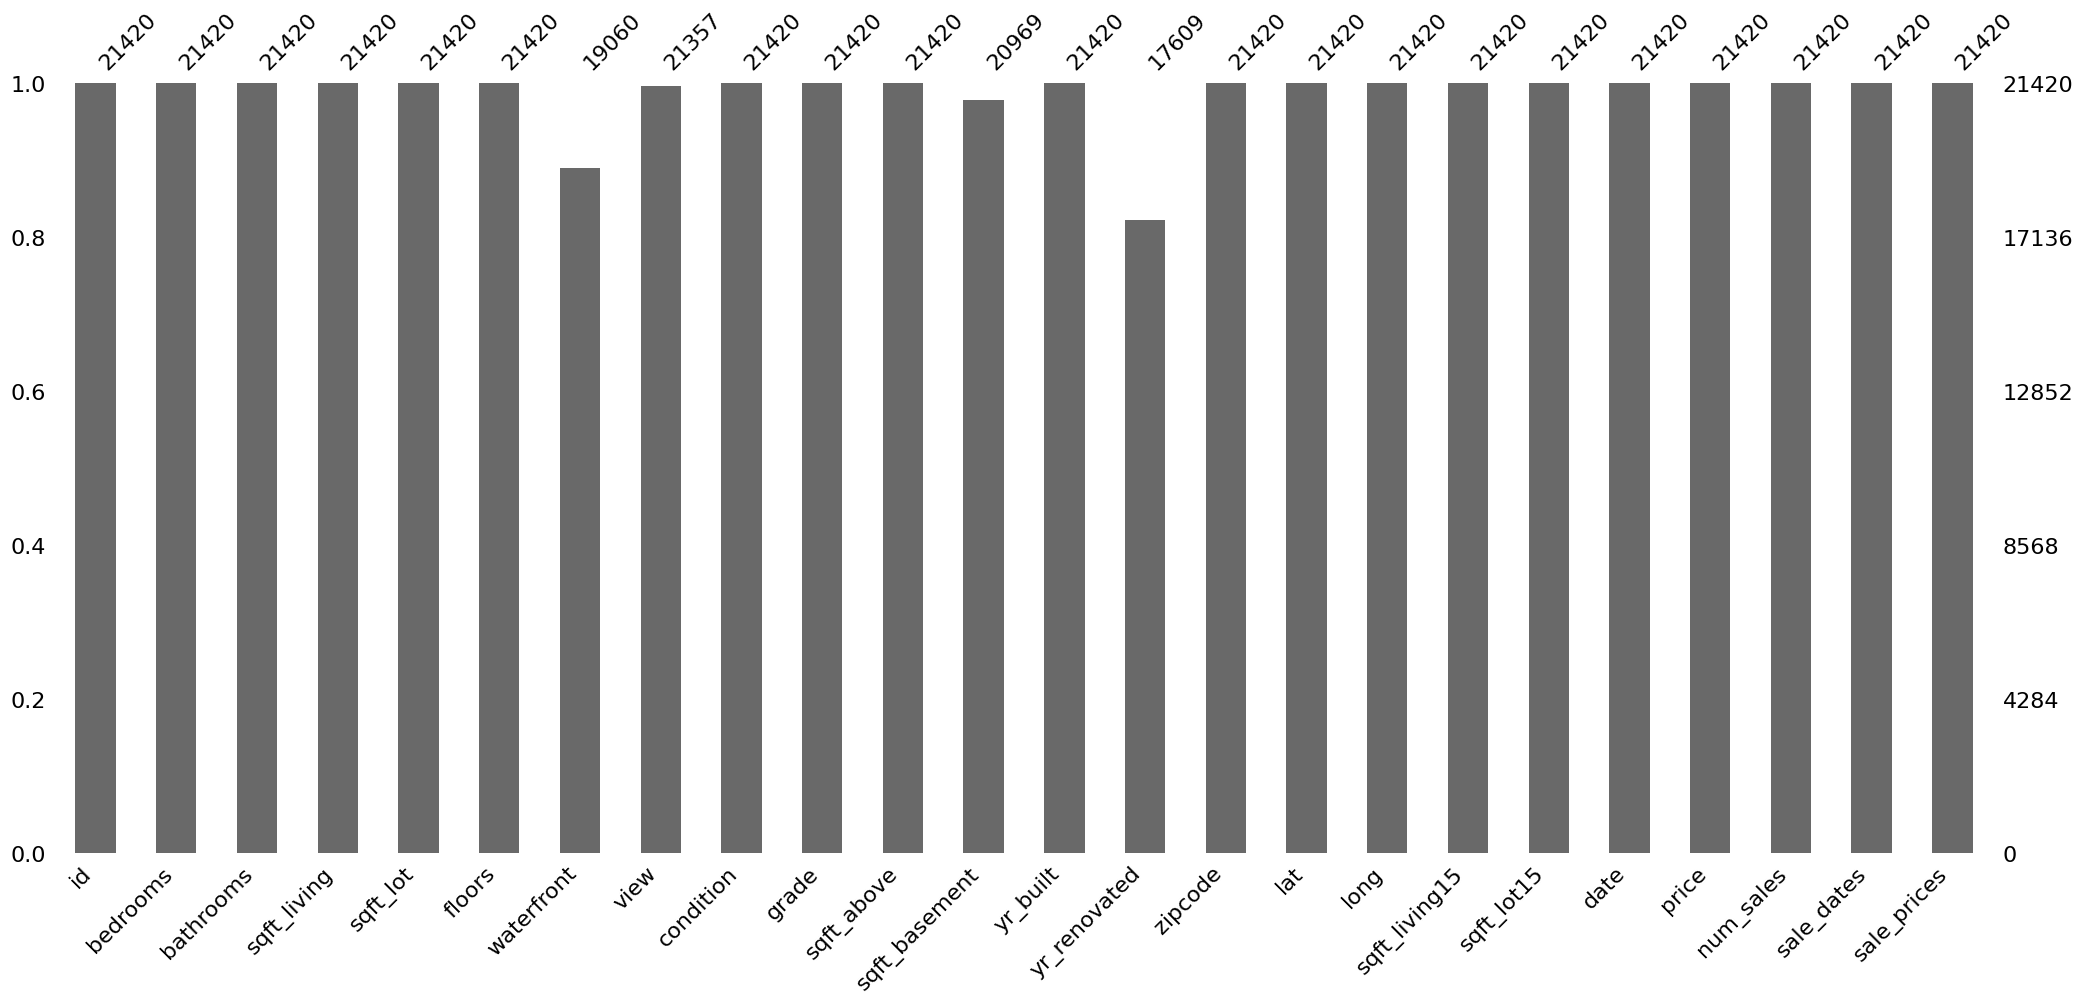

In [208]:
import missingno as msno
msno.bar(df)

<Axes: >

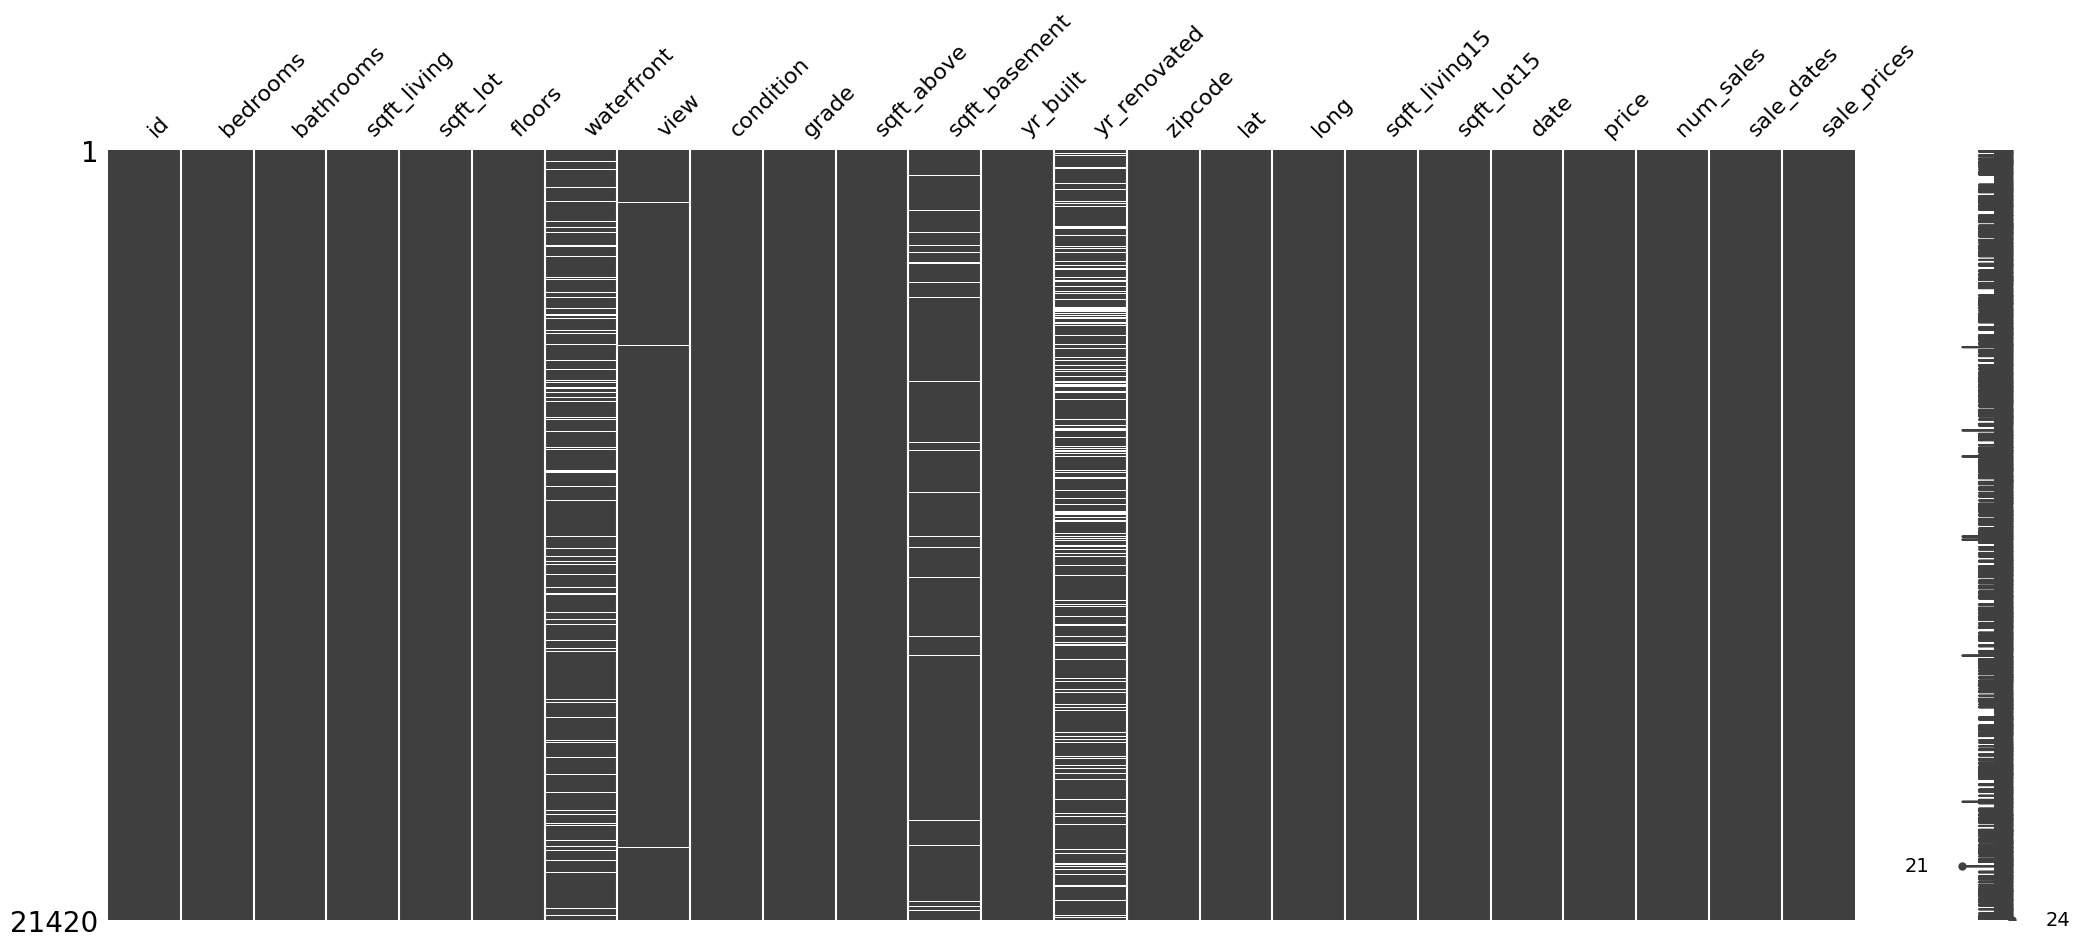

In [209]:
msno.matrix(df)

<Axes: >

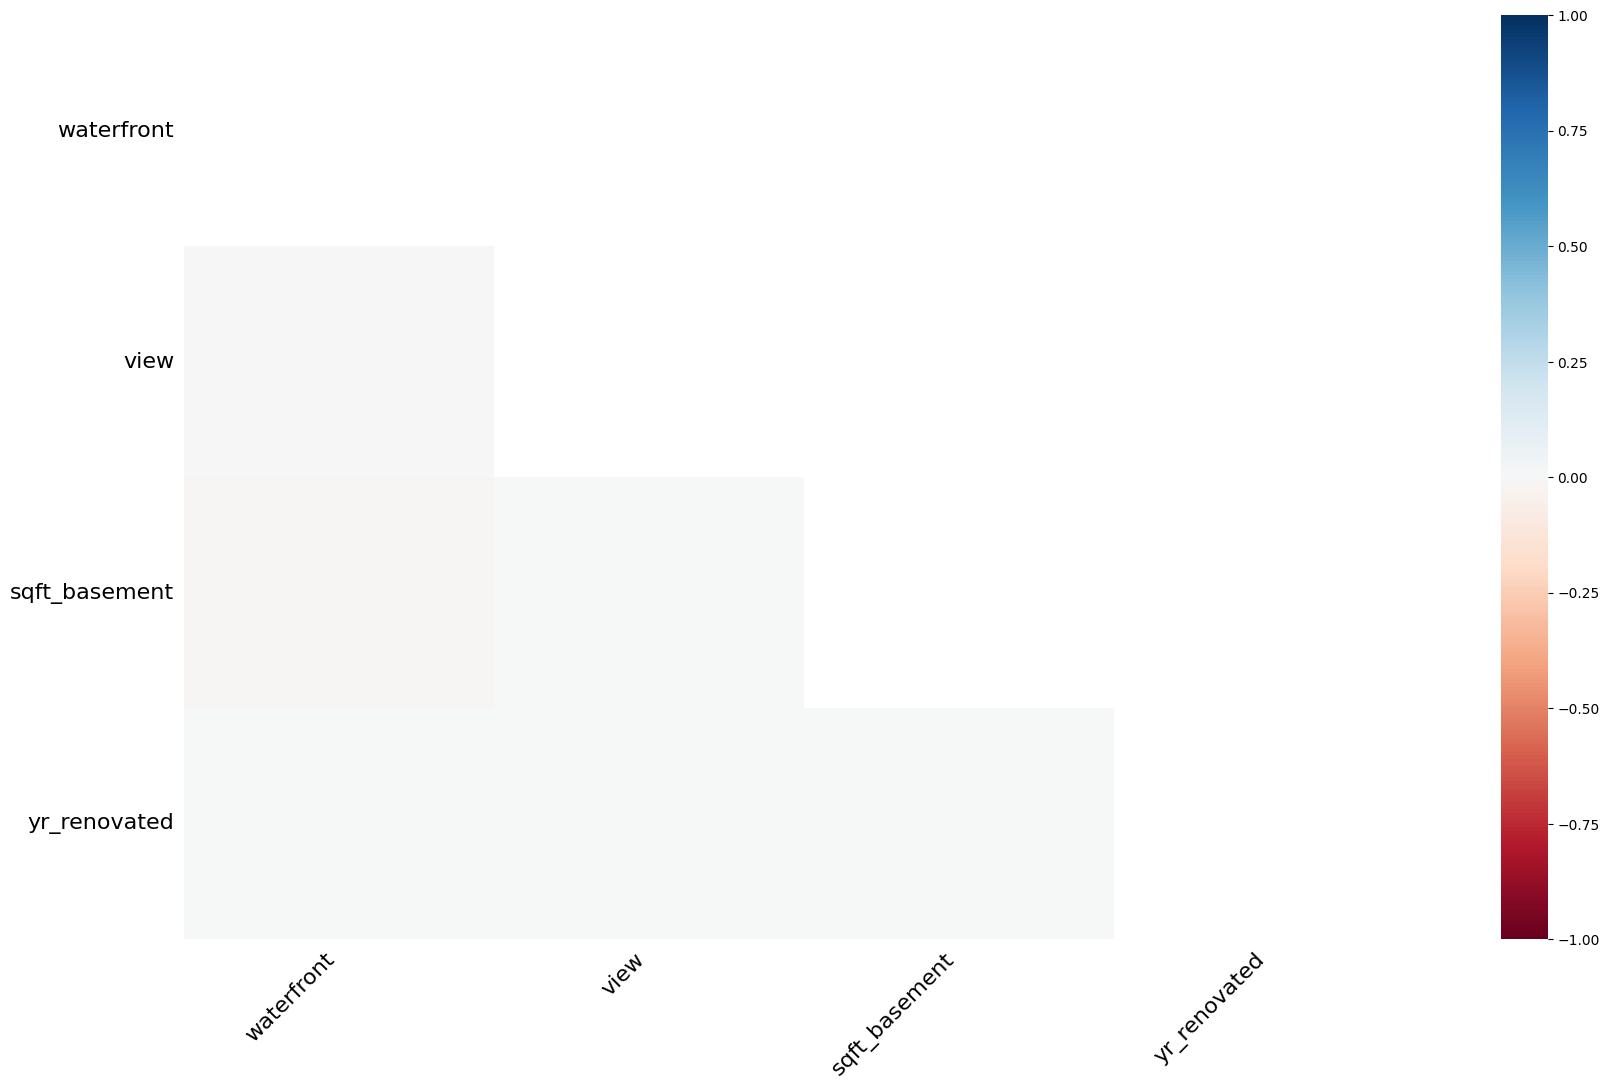

In [210]:
msno.heatmap(df)

Fixing yr-renovated col

In [211]:
df["yr_renovated"].value_counts().sort_index()

yr_renovated
0.0        16869
19340.0        1
19400.0        2
19440.0        1
19450.0        3
           ...  
20110.0        9
20120.0        8
20130.0       31
20140.0       73
20150.0       14
Name: count, Length: 70, dtype: int64

In [212]:
non_zero = df[df["yr_renovated"] > 0]["yr_renovated"]
print((non_zero % 10 == 0).all())   # True means every value ends in 0 — confirms the pattern
print(non_zero.min(), non_zero.max())

True
19340.0 20150.0


In [213]:
df.loc[df["yr_renovated"] > 0, "yr_renovated"] = df.loc[df["yr_renovated"] > 0, "yr_renovated"] / 10

In [214]:
df["yr_renovated"].value_counts().sort_index()

yr_renovated
0.0       16869
1934.0        1
1940.0        2
1944.0        1
1945.0        3
          ...  
2011.0        9
2012.0        8
2013.0       31
2014.0       73
2015.0       14
Name: count, Length: 70, dtype: int64

In [215]:
df["bedrooms"].value_counts().sort_index()

bedrooms
1      191
2     2736
3     9731
4     6849
5     1586
6      265
7       38
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64

bedrooms outlier = 33, try to fix it in the next steps ...

In [216]:
# 1. Square feet per bedroom — a bedroom needs a reasonable minimum size
df["sqft_per_bedroom"] = df["sqft_living"] / df["bedrooms"]
print(df[df["sqft_per_bedroom"] < 150][["id", "bedrooms", "bathrooms", "sqft_living", "sqft_per_bedroom"]])

# 2. A house shouldn't have many more bedrooms than bathrooms combined with small size
print(df[(df["bedrooms"] > 5) & (df["bathrooms"] < 1)][["id", "bedrooms", "bathrooms", "sqft_living"]])

# 3. sqft_above + sqft_basement should roughly equal sqft_living — flag big mismatches
df["sqft_check"] = df["sqft_above"] + df["sqft_basement"] - df["sqft_living"]
print(df[df["sqft_check"].abs() > 50][["id", "sqft_living", "sqft_above", "sqft_basement", "sqft_check"]])

              id  bedrooms  bathrooms  sqft_living  sqft_per_bedroom
4344  2402100895        33       1.75         1620         49.090909
Empty DataFrame
Columns: [id, bedrooms, bathrooms, sqft_living]
Index: []
Empty DataFrame
Columns: [id, sqft_living, sqft_above, sqft_basement, sqft_check]
Index: []


change the value 33 to 3

In [217]:
df.loc[df["bedrooms"] == 33, "bedrooms"] = 3

### Outlier Check — Box Plots

Box plots to visually spot unrealistic values across multiple columns at
once. Dots far outside the box are worth investigating (same idea as how
`bedrooms = 33` was caught). Skewed columns like `price`/`sqft_living` will
naturally show more dots — not necessarily errors.

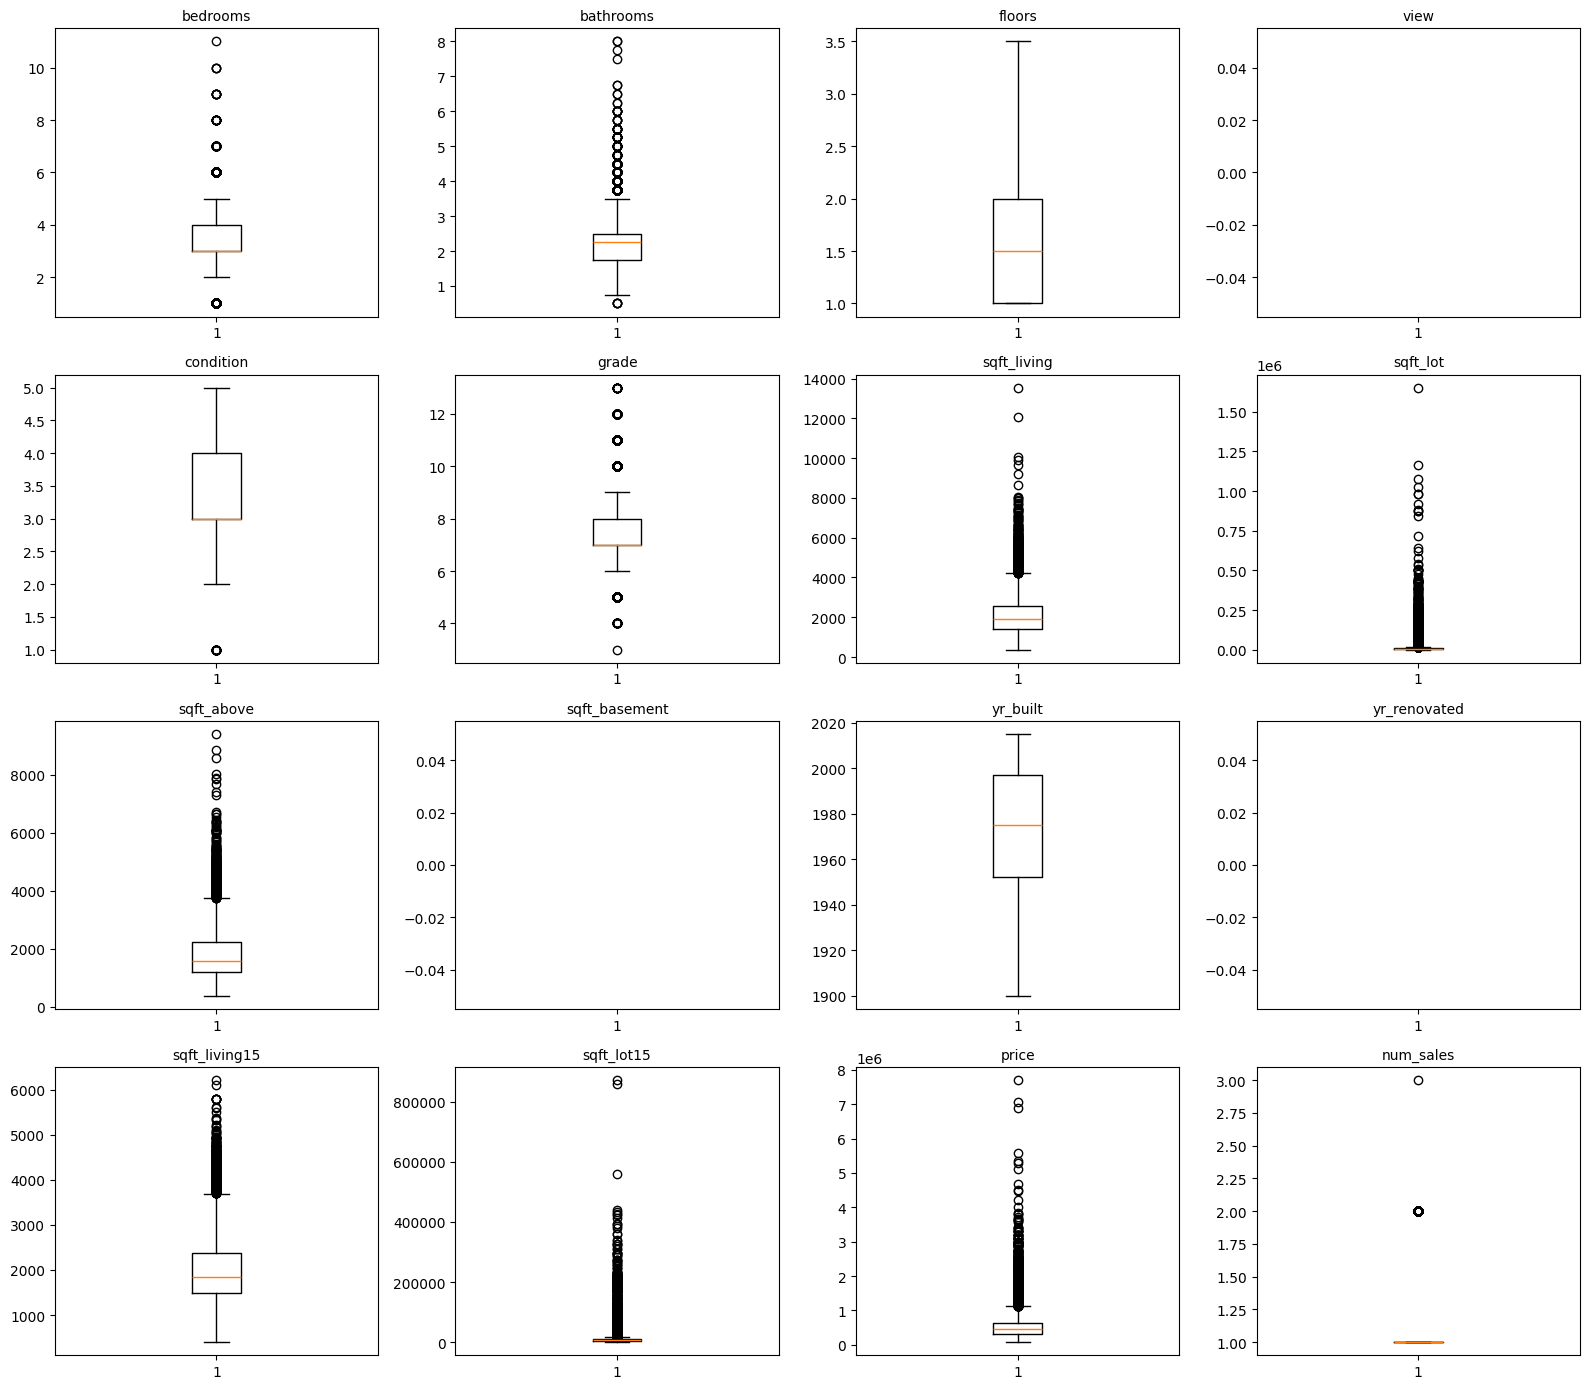

In [218]:
import matplotlib.pyplot as plt

cols_to_check = [
    "bedrooms", "bathrooms", "floors", "view", "condition", "grade",
    "sqft_living", "sqft_lot", "sqft_above", "sqft_basement",
    "yr_built", "yr_renovated", "sqft_living15", "sqft_lot15",
    "price", "num_sales"
]

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for ax, col in zip(axes, cols_to_check):
    ax.boxplot(df[col], vert=True)
    ax.set_title(col, fontsize=10)

plt.tight_layout()
plt.show()

Step 1: Confirm which of Jennifer's wish-related columns actually have missing values

In [219]:
wish_columns = [
    "price",           # high budget
    "zipcode", "lat", "long", "grade", "view", "sqft_living", "sqft_living15",  # show off
    "waterfront",       # waterfront requirement
    "yr_renovated",     # renovated
    "date", "num_sales" # resell within 1 year
]

df[wish_columns].isnull().sum()

price               0
zipcode             0
lat                 0
long                0
grade               0
view               63
sqft_living         0
sqft_living15       0
waterfront       2360
yr_renovated     3811
date                0
num_sales           0
dtype: int64

Step 2: Check the real impact on Jennifer's analysis for each of those 3 columns

In [220]:
# Jennifer's confirmed segment (using only fully-known data)
jennifer_segment = df[(df["waterfront"] == 1) & (df["grade"] >= 10)]
print(f"Confirmed segment size: {len(jennifer_segment)}")

# 1) waterfront: houses that meet her grade requirement, but waterfront status is unknown
missed_waterfront = df[(df["grade"] >= 10) & (df["waterfront"].isnull())]
print(f"Potentially missed houses (grade matches, waterfront unknown): {len(missed_waterfront)}")

# 2) view: within her confirmed segment, how many have an unknown view value (affects H1)
missed_view = jennifer_segment[jennifer_segment["view"].isnull()]
print(f"Houses in her segment with unknown view: {len(missed_view)}")

# 3) yr_renovated: across the whole dataset (affects the renovation premium in H2)
missed_renovation = df["yr_renovated"].isnull().sum()
print(f"Houses with unknown yr_renovated (dataset-wide): {missed_renovation}")

Confirmed segment size: 57
Potentially missed houses (grade matches, waterfront unknown): 164
Houses in her segment with unknown view: 1
Houses with unknown yr_renovated (dataset-wide): 3811


In [221]:
df.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price', 'num_sales',
       'sale_dates', 'sale_prices', 'sqft_per_bedroom', 'sqft_check'],
      dtype='str')

In [222]:
# Known NOT renovated
print("Known NOT renovated (yr_renovated == 0):")
print(df[df["yr_renovated"] == 0]["condition"].value_counts(normalize=True).sort_index())

# Known RENOVATED
print("\nKnown RENOVATED (yr_renovated > 0):")
print(df[df["yr_renovated"] > 0]["condition"].value_counts(normalize=True).sort_index())

# UNKNOWN (missing yr_renovated)
print("\nUNKNOWN (yr_renovated is NaN):")
print(df[df["yr_renovated"].isnull()]["condition"].value_counts(normalize=True).sort_index())

Known NOT renovated (yr_renovated == 0):
condition
1    0.001245
2    0.007884
3    0.641828
4    0.267710
5    0.081333
Name: proportion, dtype: float64

Known RENOVATED (yr_renovated > 0):
condition
1    0.001351
2    0.004054
3    0.810811
4    0.141892
5    0.041892
Name: proportion, dtype: float64

UNKNOWN (yr_renovated is NaN):
condition
1    0.001574
2    0.006822
3    0.648911
4    0.268171
5    0.074521
Name: proportion, dtype: float64


In [223]:
jennifer_clean = df[
    (df["waterfront"] == 1) &
    (df["grade"] >= 10) &
    (df["view"].notnull()) &
    (df["yr_renovated"].notnull())
]

print(f"Fully confirmed candidate houses: {len(jennifer_clean)}")

jennifer_clean[[
    "id", "price", "waterfront", "grade", "view", "zipcode", "lat", "long",
    "sqft_living", "sqft_living15", "yr_renovated",
    "condition", "bedrooms", "bathrooms", "date", "num_sales",
]]

Fully confirmed candidate houses: 46


,id,price,waterfront,grade,view,zipcode,lat,long,sqft_living,sqft_living15,yr_renovated,condition,bedrooms,bathrooms,date,num_sales
880,1247600105,5110000.0,1.0,12,4.0,98033,47.6767,-122.211,8010,3430,0.0,3,5,5.25,2014-10-20,1
1097,1324049015,2490000.0,1.0,10,3.0,98040,47.5636,-122.231,3440,4230,0.0,5,4,2.50,2014-11-11,1
2268,1724069059,2000000.0,1.0,10,4.0,98075,47.5682,-122.059,4580,2710,0.0,3,5,4.00,2014-05-24,1
3002,1924059029,4670000.0,1.0,12,4.0,98040,47.5570,-122.210,9640,3270,2009.0,3,5,6.75,2014-06-17,1
3025,1925069066,1700000.0,1.0,10,4.0,98052,47.6361,-122.093,2810,3120,0.0,4,3,2.75,2014-06-23,1
3353,2024069008,2200000.0,1.0,11,4.0,98027,47.5554,-122.077,5990,3330,0.0,3,5,4.75,2014-06-19,1
3377,2025069140,1900000.0,1.0,10,4.0,98074,47.6318,-122.071,2830,2830,0.0,3,3,2.50,2015-03-17,1
4441,2425049063,3640000.0,1.0,11,4.0,98039,47.6409,-122.241,4830,3820,0.0,4,4,3.25,2014-09-11,1
5289,2624049091,2900000.0,1.0,10,4.0,98118,47.5379,-122.264,3750,3540,0.0,3,5,2.50,2015-03-13,1
6281,2923500230,2600000.0,1.0,11,4.0,98027,47.5696,-122.090,5270,3390,0.0,3,4,4.50,2014-12-16,1


In [224]:
# instead of is_renovated, just filter/check directly:
#df[df["yr_renovated"] == 0]      # not renovated
df[df["yr_renovated"] > 0]       # renovated

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,long,sqft_living15,sqft_lot15,date,price,num_sales,sale_dates,sale_prices,sqft_per_bedroom,sqft_check
13,1005000036,3,1.75,1840,8601,1.0,0.0,0.0,3,7,...,-122.276,1390,7452,2014-06-13,285000.0,1,[2014-06-13],[285000.0],613.333333,0.0
58,1023089140,3,2.00,1740,41275,1.0,0.0,0.0,3,8,...,-121.763,2630,41275,2015-01-06,665000.0,1,[2015-01-06],[665000.0],580.000000,0.0
65,1024039049,3,2.50,2920,34527,1.0,0.0,4.0,4,9,...,-122.400,2480,7933,2014-05-12,1020000.0,1,[2014-05-12],[1020000.0],973.333333,0.0
77,1025039145,4,2.00,3140,10875,1.0,0.0,1.0,3,7,...,-122.406,3300,10080,2014-06-13,775000.0,1,[2014-06-13],[775000.0],785.000000,0.0
183,1062100100,4,2.00,2100,4857,2.0,0.0,0.0,3,8,...,-122.279,1450,5965,2014-06-26,424000.0,1,[2014-06-26],[424000.0],525.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21239,9828200746,2,1.50,1120,1024,2.0,0.0,0.0,3,8,...,-122.298,1120,1549,2015-05-04,440000.0,1,[2015-05-04],[440000.0],560.000000,0.0
21260,9828700200,4,3.00,2170,4000,2.0,0.0,0.0,4,9,...,-122.292,1670,4000,2014-05-05,831000.0,1,[2014-05-05],[831000.0],542.500000,0.0
21273,9828701690,3,2.00,1530,3400,1.0,0.0,0.0,3,7,...,-122.296,1880,4212,2014-08-06,529000.0,1,[2014-08-06],[529000.0],510.000000,0.0
21306,9829200250,3,2.00,2600,6600,2.0,0.0,4.0,3,10,...,-122.285,2670,6270,2015-01-05,1700000.0,1,[2015-01-05],[1700000.0],866.666667,0.0


In [225]:
(jennifer_clean["yr_renovated"] == 0).value_counts()

yr_renovated
True     40
False     6
Name: count, dtype: int64

In [226]:
# raw counts
#jennifer_clean[jennifer_clean["yr_renovated"] == 0]["condition"].value_counts().sort_index()
jennifer_clean[jennifer_clean["yr_renovated"] > 0]["condition"].value_counts().sort_index()

condition
3    4
4    2
Name: count, dtype: int64

In [227]:
pd.crosstab(jennifer_clean["condition"], jennifer_clean["yr_renovated"] > 0)

yr_renovated,False,True
condition,,
2,1,0
3,27,4
4,8,2
5,4,0


In [228]:
pd.crosstab(jennifer_clean["condition"], jennifer_clean["yr_renovated"] > 0, normalize="index")

yr_renovated,False,True
condition,,
2,1.000000,0.000000
3,0.870968,0.129032
4,0.800000,0.200000
5,1.000000,0.000000


### Renovation Year vs. Condition — Jennifer's Candidate Houses
Scatter plot comparing `yr_renovated` and `condition` for the 46 candidate houses,
to visually confirm the relationship seen in the cross-tab above.

In [229]:
jennifer_clean = jennifer_clean.copy()
jennifer_clean["yr_renovated"] = jennifer_clean["yr_renovated"].astype(int)

In [230]:
jennifer_clean.yr_renovated

880         0
1097        0
2268        0
3002     2009
3025        0
3353        0
3377        0
4441        0
5289        0
6281        0
6740        0
7015        0
7017        0
7526        0
7608        0
7624     1989
8441        0
8460     1987
8867        0
9785        0
10152    2002
10190       0
10495       0
11673       0
11690       0
11691       0
13090    1990
13386       0
13407       0
13410       0
13909       0
15698       0
16000       0
16259       0
16261       0
16491       0
17265       0
17648       0
17678       0
17907       0
19392       0
19920       0
19923       0
20352       0
20486       0
21208    2001
Name: yr_renovated, dtype: int64

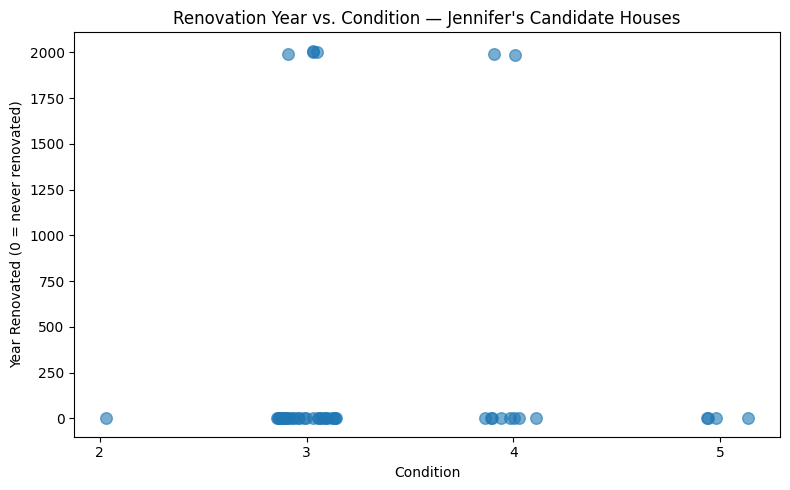

In [231]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
jitter = np.random.uniform(-0.15, 0.15, size=len(jennifer_clean))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(jennifer_clean["condition"] + jitter, jennifer_clean["yr_renovated"], alpha=0.6, s=70)
ax.set_xlabel("Condition")
ax.set_ylabel("Year Renovated (0 = never renovated)")
ax.set_title("Renovation Year vs. Condition — Jennifer's Candidate Houses")
ax.set_xticks([2, 3, 4, 5])
plt.tight_layout()
plt.savefig("condition_vs_renovation.png", dpi=150, bbox_inches="tight")
plt.show()

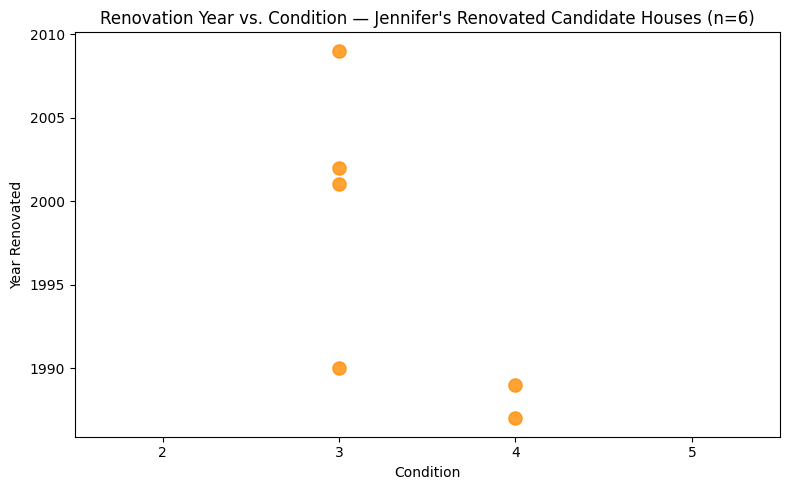

In [232]:
renovated_only = jennifer_clean[jennifer_clean["yr_renovated"] > 0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(renovated_only["condition"], renovated_only["yr_renovated"], alpha=0.8, s=90, color="darkorange")
ax.set_xlabel("Condition")
ax.set_ylabel("Year Renovated")
ax.set_title("Renovation Year vs. Condition — Jennifer's Renovated Candidate Houses (n=6)")
ax.set_xticks([2, 3, 4, 5])
ax.set_xlim(1.5, 5.5)
plt.tight_layout()
plt.savefig("condition_vs_renovation_year_only.png", dpi=150, bbox_inches="tight")
plt.show()

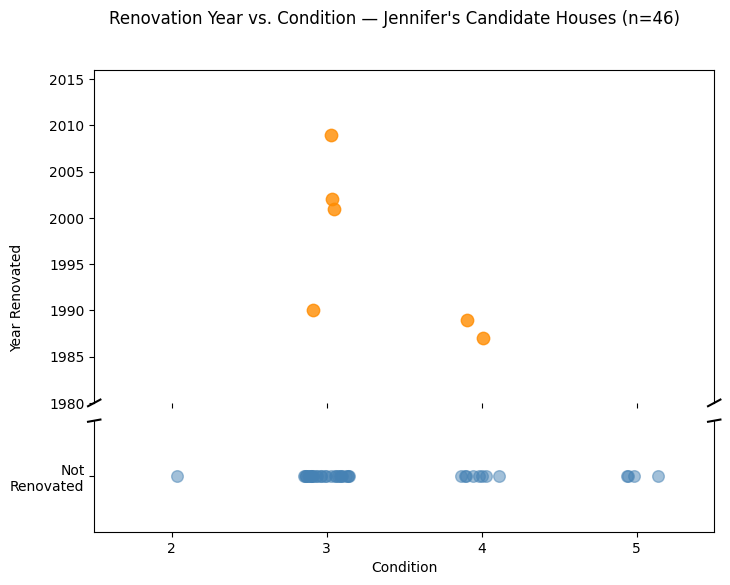

In [233]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
jitter = np.random.uniform(-0.15, 0.15, size=len(jennifer_clean))

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08}
)

# Top panel: zoomed into actual renovation years only
ax_top.scatter(jennifer_clean["condition"] + jitter, jennifer_clean["yr_renovated"],
                alpha=0.8, s=80, color="darkorange")
ax_top.set_ylim(1980, 2016)

# Bottom panel: the "not renovated" (0) band
ax_bottom.scatter(jennifer_clean["condition"] + jitter, jennifer_clean["yr_renovated"],
                   alpha=0.5, s=70, color="steelblue")
ax_bottom.set_ylim(-1, 1)
ax_bottom.set_yticks([0])
ax_bottom.set_yticklabels(["Not\nRenovated"])

# hide the connecting spines
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_top.tick_params(labelbottom=False)

# diagonal break marks to signal the axis is cut
d = 0.01
kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
kwargs.update(transform=ax_bottom.transAxes)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

ax_bottom.set_xlabel("Condition")
ax_bottom.set_xticks([2, 3, 4, 5])
ax_bottom.set_xlim(1.5, 5.5)
fig.text(0.02, 0.5, "Year Renovated", va="center", rotation="vertical")
fig.suptitle("Renovation Year vs. Condition — Jennifer's Candidate Houses (n=46)")

plt.savefig("condition_vs_renovation_broken_axis.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway:** Renovation and top condition don't overlap in Jennifer's candidate pool —
all 6 renovated houses fall at condition 3–4, while condition 5 houses were never renovated.

In [234]:
jennifer_clean.yr_built

880      1999
1097     1931
2268     2004
3002     1983
3025     1974
3353     2002
3377     2006
4441     1990
5289     1925
6281     1979
6740     1954
7015     2002
7017     1968
7526     1993
7608     1984
7624     1933
8441     1973
8460     1958
8867     1989
9785     1998
10152    1941
10190    1996
10495    1936
11673    2000
11690    2014
11691    2014
13090    1975
13386    1976
13407    1993
13410    1991
13909    1923
15698    1980
16000    2001
16259    1991
16261    1984
16491    2004
17265    1977
17648    2007
17678    1999
17907    1980
19392    1979
19920    2007
19923    1978
20352    2005
20486    1992
21208    1940
Name: yr_built, dtype: int64

In [235]:
jennifer_clean["renovation_gap"] = jennifer_clean.apply(
    lambda row: row["yr_renovated"] - row["yr_built"] if row["yr_renovated"] > 0 else None,
    axis=1
)
jennifer_clean[jennifer_clean["yr_renovated"] > 0][["id", "yr_built", "yr_renovated", "renovation_gap"]]

,id,yr_built,yr_renovated,renovation_gap
3002,1924059029,1983,2009,26.0
7624,3343302110,1933,1989,56.0
8460,3625059152,1958,1987,29.0
10152,4114601570,1941,2002,61.0
13090,6117502230,1975,1990,15.0
21208,9808700762,1940,2001,61.0


In [236]:
jennifer_clean.groupby(jennifer_clean["yr_renovated"] > 0)["yr_built"].describe()

,count,mean,std,min,25%,50%,75%,max
yr_renovated,,,,,,,,
False,40.0,1984.95,23.115041,1923.0,1977.75,1991.0,2001.25,2014.0
True,6.0,1955.00,20.484140,1933.0,1940.25,1949.5,1970.75,1983.0


In [237]:
jennifer_clean[jennifer_clean["yr_renovated"] > 0][
    ["id", "yr_built", "yr_renovated", "renovation_gap", "condition"]
]

,id,yr_built,yr_renovated,renovation_gap,condition
3002,1924059029,1983,2009,26.0,3
7624,3343302110,1933,1989,56.0,4
8460,3625059152,1958,1987,29.0,4
10152,4114601570,1941,2002,61.0,3
13090,6117502230,1975,1990,15.0,3
21208,9808700762,1940,2001,61.0,3


In [238]:
jennifer_clean["house_age_at_sale"] = jennifer_clean["date"].dt.year - jennifer_clean["yr_built"]

jennifer_clean[jennifer_clean["condition"] >= 4][
    ["id", "yr_built", "house_age_at_sale", "yr_renovated", "condition"]
].sort_values("condition", ascending=False)

,id,yr_built,house_age_at_sale,yr_renovated,condition
1097,1324049015,1931,83,0,5
8867,3761100045,1989,25,0,5
10495,4217402115,1936,79,0,5
17265,7936500109,1977,37,0,5
3025,1925069066,1974,40,0,4
4441,2425049063,1990,24,0,4
7624,3343302110,1933,82,1989,4
8441,3623500408,1973,42,0,4
8460,3625059152,1958,56,1987,4
10190,4131900066,1996,18,0,4


In [239]:
jennifer_clean[
    (jennifer_clean["yr_renovated"] > 0) | (jennifer_clean["condition"] >= 4)
][
    ["id", "yr_built", "house_age_at_sale", "yr_renovated", "renovation_gap", "condition"]
].sort_values(["condition", "yr_renovated"], ascending=[False, False])

,id,yr_built,house_age_at_sale,yr_renovated,renovation_gap,condition
1097,1324049015,1931,83,0,NaN,5
8867,3761100045,1989,25,0,NaN,5
10495,4217402115,1936,79,0,NaN,5
17265,7936500109,1977,37,0,NaN,5
7624,3343302110,1933,82,1989,56.0,4
8460,3625059152,1958,56,1987,29.0,4
3025,1925069066,1974,40,0,NaN,4
4441,2425049063,1990,24,0,NaN,4
8441,3623500408,1973,42,0,NaN,4
10190,4131900066,1996,18,0,NaN,4


### House Age vs. Condition — Renovated vs. Not Renovated
Scatter plot of house age at sale against condition score, color-coded by renovation status,
for the 18 houses in Jennifer's candidate list that are either renovated or at condition 4/5.

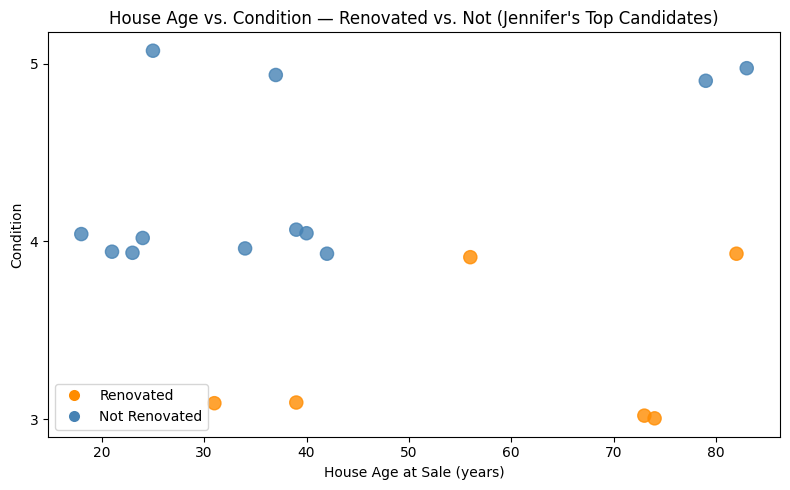

In [240]:
subset = jennifer_clean[
    (jennifer_clean["yr_renovated"] > 0) | (jennifer_clean["condition"] >= 4)
].copy()

subset["renovated_flag"] = subset["yr_renovated"] > 0
colors = subset["renovated_flag"].map({True: "darkorange", False: "steelblue"})

np.random.seed(42)
jitter = np.random.uniform(-0.1, 0.1, size=len(subset))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(subset["house_age_at_sale"], subset["condition"] + jitter, c=colors, alpha=0.8, s=90)
ax.set_xlabel("House Age at Sale (years)")
ax.set_ylabel("Condition")
ax.set_yticks([3, 4, 5])
ax.set_title("House Age vs. Condition — Renovated vs. Not (Jennifer's Top Candidates)")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=9, label='Renovated'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=9, label='Not Renovated'),
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig("age_vs_condition_renovated.png", dpi=150, bbox_inches="tight")
plt.show()

In [241]:
def assign_tier(condition):
    if condition == 5:
        return "Premium (Top Pick)"
    elif condition == 4:
        return "Strong Match"
    else:
        return "Standard Match"

jennifer_clean["quality_tier"] = jennifer_clean["condition"].apply(assign_tier)
jennifer_clean["quality_tier"].value_counts()

quality_tier
Standard Match        32
Strong Match          10
Premium (Top Pick)     4
Name: count, dtype: int64

In [242]:
jennifer_final = jennifer_clean.sort_values(["condition", "price"], ascending=[False, False])
jennifer_final[["id", "price", "zipcode", "grade", "condition", "quality_tier", "yr_renovated", "yr_built"]]

,id,price,zipcode,grade,condition,quality_tier,yr_renovated,yr_built
10495,4217402115,3650000.0,98105,11,5,Premium (Top Pick),0,1936
8867,3761100045,3000000.0,98034,10,5,Premium (Top Pick),0,1989
1097,1324049015,2490000.0,98040,10,5,Premium (Top Pick),0,1931
17265,7936500109,2230000.0,98136,10,5,Premium (Top Pick),0,1977
17907,8106100105,3850000.0,98040,11,4,Strong Match,0,1980
4441,2425049063,3640000.0,98039,11,4,Strong Match,0,1990
8460,3625059152,3300000.0,98008,11,4,Strong Match,1987,1958
13410,624069108,3200000.0,98075,12,4,Strong Match,0,1991
10190,4131900066,3100000.0,98040,11,4,Strong Match,0,1996
13407,624069035,2750000.0,98075,10,4,Strong Match,0,1993


In [243]:
jennifer_clean.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price', 'num_sales',
       'sale_dates', 'sale_prices', 'sqft_per_bedroom', 'sqft_check',
       'renovation_gap', 'house_age_at_sale', 'quality_tier'],
      dtype='str')

In [244]:
jennifer_clean["sqft_check"] = jennifer_clean["sqft_above"] + jennifer_clean["sqft_basement"] - jennifer_clean["sqft_living"]

In [245]:
jennifer_clean

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,date,price,num_sales,sale_dates,sale_prices,sqft_per_bedroom,sqft_check,renovation_gap,house_age_at_sale,quality_tier
880,1247600105,5,5.25,8010,45517,2.0,1.0,4.0,3,12,...,2014-10-20,5110000.0,1,[2014-10-20],[5110000.0],1602.000000,0.0,NaN,15,Standard Match
1097,1324049015,4,2.50,3440,23954,1.5,1.0,3.0,5,10,...,2014-11-11,2490000.0,1,[2014-11-11],[2490000.0],860.000000,0.0,NaN,83,Premium (Top Pick)
2268,1724069059,5,4.00,4580,4443,3.0,1.0,4.0,3,10,...,2014-05-24,2000000.0,1,[2014-05-24],[2000000.0],916.000000,0.0,NaN,10,Standard Match
3002,1924059029,5,6.75,9640,13068,1.0,1.0,4.0,3,12,...,2014-06-17,4670000.0,1,[2014-06-17],[4670000.0],1928.000000,0.0,26.0,31,Standard Match
3025,1925069066,3,2.75,2810,18731,2.0,1.0,4.0,4,10,...,2014-06-23,1700000.0,1,[2014-06-23],[1700000.0],936.666667,0.0,NaN,40,Strong Match
3353,2024069008,5,4.75,5990,10450,2.0,1.0,4.0,3,11,...,2014-06-19,2200000.0,1,[2014-06-19],[2200000.0],1198.000000,0.0,NaN,12,Standard Match
3377,2025069140,3,2.50,2830,4334,3.0,1.0,4.0,3,10,...,2015-03-17,1900000.0,1,[2015-03-17],[1900000.0],943.333333,0.0,NaN,9,Standard Match
4441,2425049063,4,3.25,4830,22257,2.0,1.0,4.0,4,11,...,2014-09-11,3640000.0,1,[2014-09-11],[3640000.0],1207.500000,0.0,NaN,24,Strong Match
5289,2624049091,5,2.50,3750,91681,2.0,1.0,4.0,3,10,...,2015-03-13,2900000.0,1,[2015-03-13],[2900000.0],750.000000,0.0,NaN,90,Standard Match
6281,2923500230,4,4.50,5270,12195,2.0,1.0,4.0,3,11,...,2014-12-16,2600000.0,1,[2014-12-16],[2600000.0],1317.500000,0.0,NaN,35,Standard Match


In [246]:
jennifer_clean["living_vs_neighbors"] = jennifer_clean["sqft_living"] - jennifer_clean["sqft_living15"]
jennifer_clean["lot_vs_neighbors"] = jennifer_clean["sqft_lot"] - jennifer_clean["sqft_lot15"]

jennifer_clean[
    ["id", "sqft_living", "sqft_living15", "living_vs_neighbors",
     "sqft_lot", "sqft_lot15", "lot_vs_neighbors"]
].sort_values("living_vs_neighbors", ascending=False)

,id,sqft_living,sqft_living15,living_vs_neighbors,sqft_lot,sqft_lot15,lot_vs_neighbors
3002,1924059029,9640,3270,6370,13068,10454,2614
21208,9808700762,10040,3930,6110,37325,25449,11876
880,1247600105,8010,3430,4580,45517,26788,18729
16000,7524900003,6840,3120,3720,10000,12300,-2300
16491,7738500731,6640,3030,3610,40014,23408,16606
16259,7631800015,5480,2500,2980,57990,22954,35036
3353,2024069008,5990,3330,2660,10450,14810,-4360
9785,4030100290,5170,3020,2150,7197,12880,-5683
13410,624069108,7000,4913,2087,28206,14663,13543
10495,4217402115,5480,3510,1970,19401,15810,3591


### House Size vs. Neighborhood Average — Jennifer's Candidate Houses
Scatter plot comparing each house's `sqft_living` to its neighborhood average (`sqft_living15`).
A dashed diagonal line marks where the two are equal — points above the line are bigger
than their neighbors ("standing out"), points below are smaller.

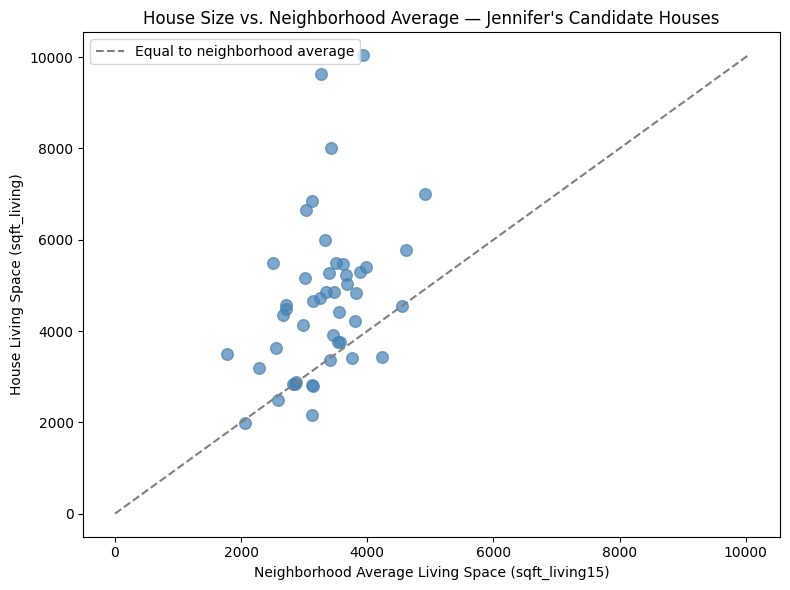

In [247]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(jennifer_clean["sqft_living15"], jennifer_clean["sqft_living"], alpha=0.7, s=70, color="steelblue")

max_val = max(jennifer_clean["sqft_living"].max(), jennifer_clean["sqft_living15"].max())
ax.plot([0, max_val], [0, max_val], linestyle="--", color="gray", label="Equal to neighborhood average")

ax.set_xlabel("Neighborhood Average Living Space (sqft_living15)")
ax.set_ylabel("House Living Space (sqft_living)")
ax.set_title("House Size vs. Neighborhood Average — Jennifer's Candidate Houses")
ax.legend()
plt.tight_layout()
plt.savefig("size_vs_neighborhood.png", dpi=150, bbox_inches="tight")
plt.show()

In [248]:
jennifer_clean

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,num_sales,sale_dates,sale_prices,sqft_per_bedroom,sqft_check,renovation_gap,house_age_at_sale,quality_tier,living_vs_neighbors,lot_vs_neighbors
880,1247600105,5,5.25,8010,45517,2.0,1.0,4.0,3,12,...,1,[2014-10-20],[5110000.0],1602.000000,0.0,NaN,15,Standard Match,4580,18729
1097,1324049015,4,2.50,3440,23954,1.5,1.0,3.0,5,10,...,1,[2014-11-11],[2490000.0],860.000000,0.0,NaN,83,Premium (Top Pick),-790,5231
2268,1724069059,5,4.00,4580,4443,3.0,1.0,4.0,3,10,...,1,[2014-05-24],[2000000.0],916.000000,0.0,NaN,10,Standard Match,1870,0
3002,1924059029,5,6.75,9640,13068,1.0,1.0,4.0,3,12,...,1,[2014-06-17],[4670000.0],1928.000000,0.0,26.0,31,Standard Match,6370,2614
3025,1925069066,3,2.75,2810,18731,2.0,1.0,4.0,4,10,...,1,[2014-06-23],[1700000.0],936.666667,0.0,NaN,40,Strong Match,-310,3921
3353,2024069008,5,4.75,5990,10450,2.0,1.0,4.0,3,11,...,1,[2014-06-19],[2200000.0],1198.000000,0.0,NaN,12,Standard Match,2660,-4360
3377,2025069140,3,2.50,2830,4334,3.0,1.0,4.0,3,10,...,1,[2015-03-17],[1900000.0],943.333333,0.0,NaN,9,Standard Match,0,-33877
4441,2425049063,4,3.25,4830,22257,2.0,1.0,4.0,4,11,...,1,[2014-09-11],[3640000.0],1207.500000,0.0,NaN,24,Strong Match,1010,-3325
5289,2624049091,5,2.50,3750,91681,2.0,1.0,4.0,3,10,...,1,[2015-03-13],[2900000.0],750.000000,0.0,NaN,90,Standard Match,210,67388
6281,2923500230,4,4.50,5270,12195,2.0,1.0,4.0,3,11,...,1,[2014-12-16],[2600000.0],1317.500000,0.0,NaN,35,Standard Match,1880,2290


In [249]:
# County-wide ranking (the benchmark)
zip_avg_price = df.groupby("zipcode")["price"].mean().sort_values(ascending=False)

# Jennifer's own list, averaged by zip
jennifer_zip_avg = jennifer_clean.groupby("zipcode")["price"].mean().sort_values(ascending=False)

# Where do Jennifer's zip codes rank within the full county list?
zip_avg_price[zip_avg_price.index.isin(jennifer_clean["zipcode"].unique())]

zipcode
98039    2.187551e+06
98004    1.355972e+06
98040    1.194874e+06
98105    8.632289e+05
98006    8.581498e+05
98033    8.040639e+05
98075    7.916027e+05
98074    6.895628e+05
98052    6.463397e+05
98008    6.456282e+05
98116    6.199632e+05
98027    6.172049e+05
98144    5.965687e+05
98136    5.517685e+05
98034    5.222989e+05
98166    4.679146e+05
98028    4.624268e+05
98155    4.248307e+05
98056    4.218120e+05
98118    4.212872e+05
98178    3.128509e+05
Name: price, dtype: float64

In [250]:
jennifer_clean[jennifer_clean["id"] == 7631800110]["zipcode"]

16261    98166
Name: zipcode, dtype: str

In [251]:
zip_avg_price = df.groupby("zipcode")["price"].mean()

jennifer_clean["zip_avg_price"] = jennifer_clean["zipcode"].map(zip_avg_price)
jennifer_clean["price_vs_zip_avg"] = jennifer_clean["price"] - jennifer_clean["zip_avg_price"]

jennifer_clean[
    ["id", "zipcode", "price", "zip_avg_price", "price_vs_zip_avg"]
].sort_values("price_vs_zip_avg", ascending=False)

,id,zipcode,price,zip_avg_price,price_vs_zip_avg
21208,9808700762,98004,7060000.0,1.355972e+06,5.704028e+06
880,1247600105,98033,5110000.0,8.040639e+05,4.305936e+06
16491,7738500731,98155,4500000.0,4.248307e+05,4.075169e+06
3002,1924059029,98040,4670000.0,1.194874e+06,3.475126e+06
10152,4114601570,98144,3600000.0,5.965687e+05,3.003431e+06
19920,9253900271,98008,3570000.0,6.456282e+05,2.924372e+06
10495,4217402115,98105,3650000.0,8.632289e+05,2.786771e+06
17907,8106100105,98040,3850000.0,1.194874e+06,2.655126e+06
8460,3625059152,98008,3300000.0,6.456282e+05,2.654372e+06
16000,7524900003,98008,3280000.0,6.456282e+05,2.634372e+06


In [252]:
pd.set_option("display.max_columns", None)
jennifer_clean

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,num_sales,sale_dates,sale_prices,sqft_per_bedroom,sqft_check,renovation_gap,house_age_at_sale,quality_tier,living_vs_neighbors,lot_vs_neighbors,zip_avg_price,price_vs_zip_avg
880,1247600105,5,5.25,8010,45517,2.0,1.0,4.0,3,12,5990,2020.0,1999,0,98033,47.6767,-122.211,3430,26788,2014-10-20,5110000.0,1,[2014-10-20],[5110000.0],1602.000000,0.0,NaN,15,Standard Match,4580,18729,8.040639e+05,4.305936e+06
1097,1324049015,4,2.50,3440,23954,1.5,1.0,3.0,5,10,2260,1180.0,1931,0,98040,47.5636,-122.231,4230,18723,2014-11-11,2490000.0,1,[2014-11-11],[2490000.0],860.000000,0.0,NaN,83,Premium (Top Pick),-790,5231,1.194874e+06,1.295126e+06
2268,1724069059,5,4.00,4580,4443,3.0,1.0,4.0,3,10,4580,0.0,2004,0,98075,47.5682,-122.059,2710,4443,2014-05-24,2000000.0,1,[2014-05-24],[2000000.0],916.000000,0.0,NaN,10,Standard Match,1870,0,7.916027e+05,1.208397e+06
3002,1924059029,5,6.75,9640,13068,1.0,1.0,4.0,3,12,4820,4820.0,1983,2009,98040,47.5570,-122.210,3270,10454,2014-06-17,4670000.0,1,[2014-06-17],[4670000.0],1928.000000,0.0,26.0,31,Standard Match,6370,2614,1.194874e+06,3.475126e+06
3025,1925069066,3,2.75,2810,18731,2.0,1.0,4.0,4,10,2810,0.0,1974,0,98052,47.6361,-122.093,3120,14810,2014-06-23,1700000.0,1,[2014-06-23],[1700000.0],936.666667,0.0,NaN,40,Strong Match,-310,3921,6.463397e+05,1.053660e+06
3353,2024069008,5,4.75,5990,10450,2.0,1.0,4.0,3,11,4050,1940.0,2002,0,98027,47.5554,-122.077,3330,14810,2014-06-19,2200000.0,1,[2014-06-19],[2200000.0],1198.000000,0.0,NaN,12,Standard Match,2660,-4360,6.172049e+05,1.582795e+06
3377,2025069140,3,2.50,2830,4334,3.0,1.0,4.0,3,10,2830,0.0,2006,0,98074,47.6318,-122.071,2830,38211,2015-03-17,1900000.0,1,[2015-03-17],[1900000.0],943.333333,0.0,NaN,9,Standard Match,0,-33877,6.895628e+05,1.210437e+06
4441,2425049063,4,3.25,4830,22257,2.0,1.0,4.0,4,11,4830,0.0,1990,0,98039,47.6409,-122.241,3820,25582,2014-09-11,3640000.0,1,[2014-09-11],[3640000.0],1207.500000,0.0,NaN,24,Strong Match,1010,-3325,2.187551e+06,1.452449e+06
5289,2624049091,5,2.50,3750,91681,2.0,1.0,4.0,3,10,3750,0.0,1925,0,98118,47.5379,-122.264,3540,24293,2015-03-13,2900000.0,1,[2015-03-13],[2900000.0],750.000000,0.0,NaN,90,Standard Match,210,67388,4.212872e+05,2.478713e+06
6281,2923500230,4,4.50,5270,12195,2.0,1.0,4.0,3,11,3400,1870.0,1979,0,98027,47.5696,-122.090,3390,9905,2014-12-16,2600000.0,1,[2014-12-16],[2600000.0],1317.500000,0.0,NaN,35,Standard Match,1880,2290,6.172049e+05,1.982795e+06


In [253]:
zip_avg_price_full = df.groupby("zipcode")["price"].mean()

q75 = zip_avg_price_full.quantile(0.75)
q25 = zip_avg_price_full.quantile(0.25)

def location_tier(zip_price):
    if zip_price >= q75:
        return "Prestige Location"
    elif zip_price >= q25:
        return "Mid-Tier Location"
    else:
        return "Modest Location"

jennifer_clean["location_tier"] = jennifer_clean["zip_avg_price"].apply(location_tier)
jennifer_clean["location_tier"].value_counts()

location_tier
Mid-Tier Location    24
Prestige Location    21
Modest Location       1
Name: count, dtype: int64

In [254]:
jennifer_clean[
    ["id", "zipcode", "zip_avg_price", "location_tier", "price"]
].sort_values("zip_avg_price", ascending=False)

,id,zipcode,zip_avg_price,location_tier,price
4441,2425049063,98039,2.187551e+06,Prestige Location,3640000.0
21208,9808700762,98004,1.355972e+06,Prestige Location,7060000.0
20352,9362000040,98040,1.194874e+06,Prestige Location,3400000.0
3002,1924059029,98040,1.194874e+06,Prestige Location,4670000.0
17907,8106100105,98040,1.194874e+06,Prestige Location,3850000.0
1097,1324049015,98040,1.194874e+06,Prestige Location,2490000.0
10190,4131900066,98040,1.194874e+06,Prestige Location,3100000.0
8441,3623500408,98040,1.194874e+06,Prestige Location,2600000.0
13909,6613000935,98105,8.632289e+05,Prestige Location,2560000.0
10495,4217402115,98105,8.632289e+05,Prestige Location,3650000.0


### Jennifer's Candidate Houses by Location Prestige Tier
Scatter plot of house locations (lat/long), color-coded by whether the zip code sits in the
top 25% (Prestige), middle 50% (Mid-Tier), or bottom 25% (Modest) of King County by average price.

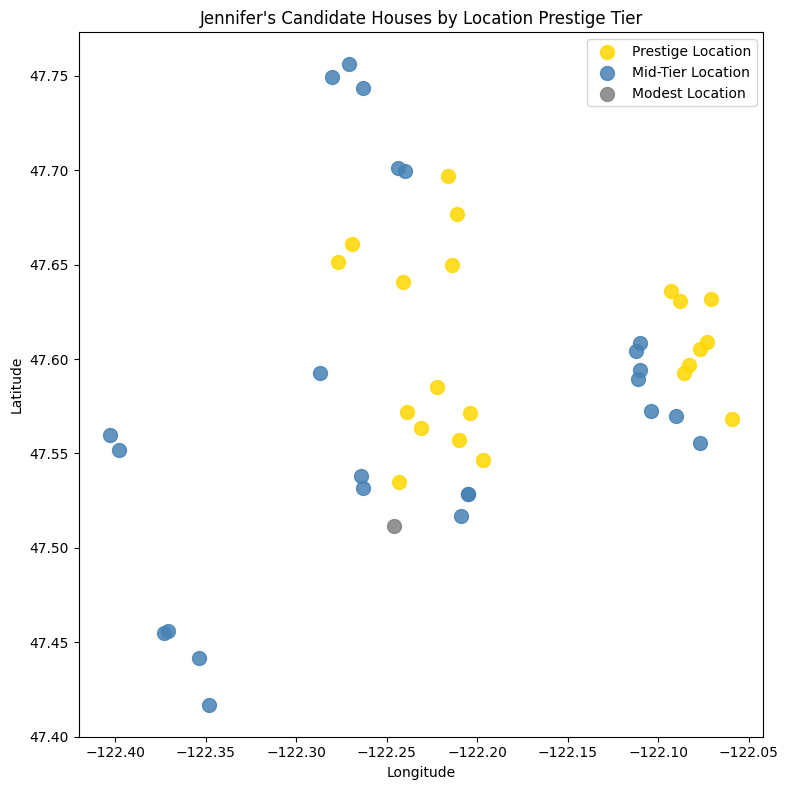

In [255]:
import matplotlib.pyplot as plt

colors = {"Prestige Location": "gold", "Mid-Tier Location": "steelblue", "Modest Location": "gray"}

fig, ax = plt.subplots(figsize=(8, 8))
for tier, color in colors.items():
    subset = jennifer_clean[jennifer_clean["location_tier"] == tier]
    ax.scatter(subset["long"], subset["lat"], c=color, label=tier, alpha=0.85, s=100)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Jennifer's Candidate Houses by Location Prestige Tier")
ax.legend()
plt.tight_layout()
plt.savefig("jennifer_location_map.png", dpi=150, bbox_inches="tight")
plt.show()

In [256]:
jennifer_clean[["id", "floors", "sqft_living", "price", "zipcode", "location_tier"]].sort_values(
    ["floors", "sqft_living"], ascending=[False, False]
)

,id,floors,sqft_living,price,zipcode,location_tier
9785,4030100290,3.0,5170,1680000.0,98155,Mid-Tier Location
2268,1724069059,3.0,4580,2000000.0,98075,Prestige Location
7608,3342104046,3.0,2890,1570000.0,98056,Mid-Tier Location
3377,2025069140,3.0,2830,1900000.0,98074,Prestige Location
16000,7524900003,2.5,6840,3280000.0,98008,Mid-Tier Location
17648,8043700105,2.5,4360,2300000.0,98008,Mid-Tier Location
21208,9808700762,2.0,10040,7060000.0,98004,Prestige Location
880,1247600105,2.0,8010,5110000.0,98033,Prestige Location
16491,7738500731,2.0,6640,4500000.0,98155,Mid-Tier Location
3353,2024069008,2.0,5990,2200000.0,98027,Mid-Tier Location


### Floors vs. Size — Jennifer's Candidate Houses
Scatter plot of floor count against living space, colored by price, to check whether
more floors actually means a bigger, more expensive ("castle-like") house.

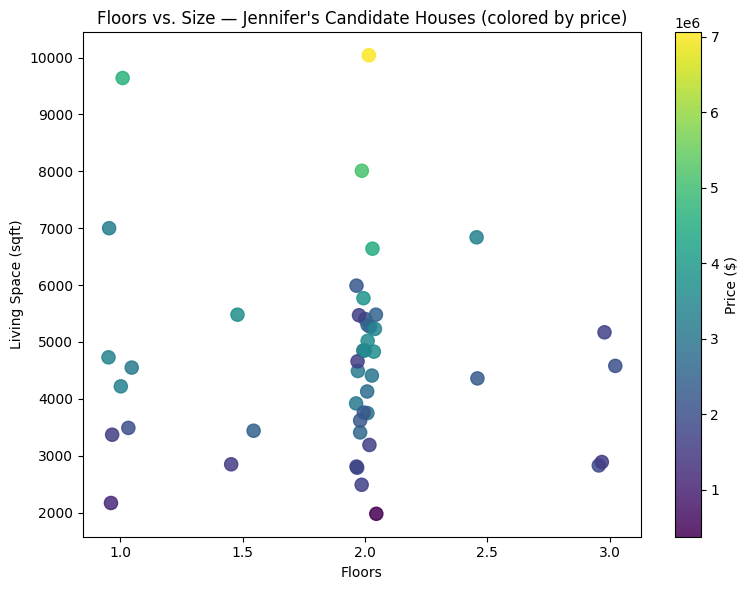

In [257]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
jitter = np.random.uniform(-0.05, 0.05, size=len(jennifer_clean))

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    jennifer_clean["floors"] + jitter,
    jennifer_clean["sqft_living"],
    c=jennifer_clean["price"],
    cmap="viridis",
    s=90,
    alpha=0.85
)
ax.set_xlabel("Floors")
ax.set_ylabel("Living Space (sqft)")
ax.set_title("Floors vs. Size — Jennifer's Candidate Houses (colored by price)")
ax.set_xticks([1.0, 1.5, 2.0, 2.5, 3.0])
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Price ($)")
plt.tight_layout()
plt.savefig("floors_vs_size_price.png", dpi=150, bbox_inches="tight")
plt.show()

In [258]:
qualifying = df[(df["waterfront"] == 1) & (df["grade"] >= 10)]
qualifying["sale_month"] = qualifying["date"].dt.to_period("M")
qualifying["sale_month"].value_counts().sort_index()

sale_month
2014-05    3
2014-06    9
2014-07    3
2014-08    5
2014-09    6
2014-10    3
2014-11    5
2014-12    5
2015-01    2
2015-02    1
2015-03    7
2015-04    8
Freq: M, Name: count, dtype: int64

In [259]:
jennifer_clean["sale_month"] = jennifer_clean["date"].dt.to_period("M")
jennifer_clean["sale_month"].value_counts().sort_index()

sale_month
2014-05    2
2014-06    8
2014-07    3
2014-08    4
2014-09    2
2014-10    3
2014-11    5
2014-12    5
2015-01    2
2015-02    1
2015-03    5
2015-04    6
Freq: M, Name: count, dtype: int64

## Wish 4 — Timing Within a Month

**Limitation:** This dataset contains only historical, completed sales (a final `date` per house).
It has no listing date, "days on market," or live availability status — so purchase speed
cannot be measured directly.

**Approach:** Using Jennifer's 46 fully-qualifying candidate houses (`jennifer_clean`), we grouped
sales by month across the available year of data (May 2014 – April 2015) as a proxy for how often
a matching house appears on the market.

**Finding:** Matching houses appear at an average rate of **3.83 per month**, ranging from as few
as **1** (February 2015) to as many as **8** (June 2014).

**Takeaway:** Regardless of which month Jennifer starts her search, she should expect only a
handful of real options within any given month — a narrow window for a one-month timeline.

**Recommendation:** Work with an agent who can flag new matching listings immediately; comparing
multiple options within a single month may not be realistic given how rarely qualifying houses appear.

In [260]:
price_percentile = (df["price"] < jennifer_clean["price"].min()).mean() * 100
print(f"The cheapest house in Jennifer's list is more expensive than {price_percentile:.1f}% of all King County houses.")

The cheapest house in Jennifer's list is more expensive than 36.3% of all King County houses.


In [261]:
price_percentiles = jennifer_clean["price"].apply(lambda p: (df["price"] < p).mean() * 100)
price_percentiles.describe()

count    46.000000
mean     97.837555
std       9.327173
min      36.279178
25%      98.642624
50%      99.596172
75%      99.854108
max      99.990663
Name: price, dtype: float64

In [262]:
repeat_sold = df[df["num_sales"] > 1].copy()

def compute_gap_and_change(row):
    pairs = sorted(zip(pd.to_datetime(row["sale_dates"]), row["sale_prices"]))
    dates_sorted = [d for d, p in pairs]
    prices_sorted = [p for d, p in pairs]
    gap_days = (dates_sorted[-1] - dates_sorted[0]).days
    price_change = prices_sorted[-1] - prices_sorted[0]
    pct_change = (price_change / prices_sorted[0]) * 100
    return pd.Series({"gap_days": gap_days, "price_change": price_change, "pct_change": pct_change})

repeat_sold[["gap_days", "price_change", "pct_change"]] = repeat_sold.apply(compute_gap_and_change, axis=1)

repeat_sold[["id", "gap_days", "price_change", "pct_change"]].sort_values("gap_days")

,id,gap_days,price_change,pct_change
280,109200390,61.0,5000.0,2.040816
809,1237500540,62.0,45000.0,20.000000
2710,1825069031,63.0,0.0,0.000000
16424,7701960990,64.0,8000.0,0.928074
5845,2787460720,68.0,59950.0,29.975000
...,...,...,...,...
17155,7893805650,312.0,265000.0,126.190476
12863,6021500970,314.0,529950.0,153.608696
13088,6117501820,314.0,184725.0,73.808810
18472,8645530010,314.0,70000.0,31.111111


In [263]:
quick_resales = repeat_sold[repeat_sold["gap_days"] <= 365]
quick_resales[["id", "gap_days", "price_change", "pct_change"]].sort_values("gap_days")

,id,gap_days,price_change,pct_change
280,109200390,61.0,5000.0,2.040816
809,1237500540,62.0,45000.0,20.000000
2710,1825069031,63.0,0.0,0.000000
16424,7701960990,64.0,8000.0,0.928074
5845,2787460720,68.0,59950.0,29.975000
...,...,...,...,...
17155,7893805650,312.0,265000.0,126.190476
12863,6021500970,314.0,529950.0,153.608696
13088,6117501820,314.0,184725.0,73.808810
18472,8645530010,314.0,70000.0,31.111111


In [264]:
jennifer_clean["num_sales"].value_counts()

num_sales
1    46
Name: count, dtype: int64

In [265]:
repeat_sold = df[df["num_sales"] > 1].copy()
comparable_repeat_sold = repeat_sold[repeat_sold["grade"] >= 10]
comparable_repeat_sold[["id", "grade", "price", "num_sales", "sale_dates", "sale_prices"]]

,id,grade,price,num_sales,sale_dates,sale_prices
8166,3528000040,11,1800000.0,2,"[2014-10-01, 2015-03-26]","[1690000.0, 1800000.0]"
10251,4139420590,12,1200000.0,2,"[2014-05-20, 2014-08-27]","[1210000.0, 1200000.0]"
10262,4139440480,10,796500.0,2,"[2014-06-26, 2014-12-01]","[695000.0, 796500.0]"
10273,4139480200,11,1400000.0,2,"[2014-06-18, 2014-12-09]","[1380000.0, 1400000.0]"
14840,7167000040,10,700000.0,2,"[2014-08-13, 2015-03-05]","[740000.0, 700000.0]"
16424,7701960990,11,870000.0,2,"[2014-06-16, 2014-08-19]","[862000.0, 870000.0]"
16994,7856400240,10,1650000.0,2,"[2014-06-27, 2015-02-11]","[1620000.0, 1650000.0]"
16995,7856400300,10,1510000.0,2,"[2014-07-02, 2015-03-22]","[1410000.0, 1510000.0]"


In [266]:
def compute_gap_and_change(row):
    pairs = sorted(zip(pd.to_datetime(row["sale_dates"]), row["sale_prices"]))
    dates_sorted = [d for d, p in pairs]
    prices_sorted = [p for d, p in pairs]
    gap_days = (dates_sorted[-1] - dates_sorted[0]).days
    price_change = prices_sorted[-1] - prices_sorted[0]
    pct_change = (price_change / prices_sorted[0]) * 100
    return pd.Series({"gap_days": gap_days, "price_change": price_change, "pct_change": pct_change})

comparable_repeat_sold[["gap_days", "price_change", "pct_change"]] = comparable_repeat_sold.apply(compute_gap_and_change, axis=1)

comparable_repeat_sold[["id", "grade", "gap_days", "price_change", "pct_change"]].sort_values("gap_days")

,id,grade,gap_days,price_change,pct_change
16424,7701960990,11,64.0,8000.0,0.928074
10251,4139420590,12,99.0,-10000.0,-0.826446
10262,4139440480,10,158.0,101500.0,14.604317
10273,4139480200,11,174.0,20000.0,1.449275
8166,3528000040,11,176.0,110000.0,6.508876
14840,7167000040,10,204.0,-40000.0,-5.405405
16994,7856400240,10,229.0,30000.0,1.851852
16995,7856400300,10,263.0,100000.0,7.092199


In [267]:
comparable_repeat_sold[
    ["id", "grade", "waterfront", "view", "condition", "price", "zipcode"]
]

,id,grade,waterfront,view,condition,price,zipcode
8166,3528000040,11,0.0,0.0,4,1800000.0,98053
10251,4139420590,12,0.0,3.0,3,1200000.0,98006
10262,4139440480,10,0.0,0.0,3,796500.0,98006
10273,4139480200,11,0.0,3.0,3,1400000.0,98006
14840,7167000040,10,0.0,0.0,3,700000.0,98010
16424,7701960990,11,0.0,0.0,3,870000.0,98077
16994,7856400240,10,NaN,4.0,5,1650000.0,98006
16995,7856400300,10,0.0,4.0,5,1510000.0,98006


In [268]:
pd.set_option("display.max_columns", None)
jennifer_clean

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,num_sales,sale_dates,sale_prices,sqft_per_bedroom,sqft_check,renovation_gap,house_age_at_sale,quality_tier,living_vs_neighbors,lot_vs_neighbors,zip_avg_price,price_vs_zip_avg,location_tier,sale_month
880,1247600105,5,5.25,8010,45517,2.0,1.0,4.0,3,12,5990,2020.0,1999,0,98033,47.6767,-122.211,3430,26788,2014-10-20,5110000.0,1,[2014-10-20],[5110000.0],1602.000000,0.0,NaN,15,Standard Match,4580,18729,8.040639e+05,4.305936e+06,Prestige Location,2014-10
1097,1324049015,4,2.50,3440,23954,1.5,1.0,3.0,5,10,2260,1180.0,1931,0,98040,47.5636,-122.231,4230,18723,2014-11-11,2490000.0,1,[2014-11-11],[2490000.0],860.000000,0.0,NaN,83,Premium (Top Pick),-790,5231,1.194874e+06,1.295126e+06,Prestige Location,2014-11
2268,1724069059,5,4.00,4580,4443,3.0,1.0,4.0,3,10,4580,0.0,2004,0,98075,47.5682,-122.059,2710,4443,2014-05-24,2000000.0,1,[2014-05-24],[2000000.0],916.000000,0.0,NaN,10,Standard Match,1870,0,7.916027e+05,1.208397e+06,Prestige Location,2014-05
3002,1924059029,5,6.75,9640,13068,1.0,1.0,4.0,3,12,4820,4820.0,1983,2009,98040,47.5570,-122.210,3270,10454,2014-06-17,4670000.0,1,[2014-06-17],[4670000.0],1928.000000,0.0,26.0,31,Standard Match,6370,2614,1.194874e+06,3.475126e+06,Prestige Location,2014-06
3025,1925069066,3,2.75,2810,18731,2.0,1.0,4.0,4,10,2810,0.0,1974,0,98052,47.6361,-122.093,3120,14810,2014-06-23,1700000.0,1,[2014-06-23],[1700000.0],936.666667,0.0,NaN,40,Strong Match,-310,3921,6.463397e+05,1.053660e+06,Prestige Location,2014-06
3353,2024069008,5,4.75,5990,10450,2.0,1.0,4.0,3,11,4050,1940.0,2002,0,98027,47.5554,-122.077,3330,14810,2014-06-19,2200000.0,1,[2014-06-19],[2200000.0],1198.000000,0.0,NaN,12,Standard Match,2660,-4360,6.172049e+05,1.582795e+06,Mid-Tier Location,2014-06
3377,2025069140,3,2.50,2830,4334,3.0,1.0,4.0,3,10,2830,0.0,2006,0,98074,47.6318,-122.071,2830,38211,2015-03-17,1900000.0,1,[2015-03-17],[1900000.0],943.333333,0.0,NaN,9,Standard Match,0,-33877,6.895628e+05,1.210437e+06,Prestige Location,2015-03
4441,2425049063,4,3.25,4830,22257,2.0,1.0,4.0,4,11,4830,0.0,1990,0,98039,47.6409,-122.241,3820,25582,2014-09-11,3640000.0,1,[2014-09-11],[3640000.0],1207.500000,0.0,NaN,24,Strong Match,1010,-3325,2.187551e+06,1.452449e+06,Prestige Location,2014-09
5289,2624049091,5,2.50,3750,91681,2.0,1.0,4.0,3,10,3750,0.0,1925,0,98118,47.5379,-122.264,3540,24293,2015-03-13,2900000.0,1,[2015-03-13],[2900000.0],750.000000,0.0,NaN,90,Standard Match,210,67388,4.212872e+05,2.478713e+06,Mid-Tier Location,2015-03
6281,2923500230,4,4.50,5270,12195,2.0,1.0,4.0,3,11,3400,1870.0,1979,0,98027,47.5696,-122.090,3390,9905,2014-12-16,2600000.0,1,[2014-12-16],[2600000.0],1317.500000,0.0,NaN,35,Standard Match,1880,2290,6.172049e+05,1.982795e+06,Mid-Tier Location,2014-12


In [269]:
top_picks = jennifer_clean[
    (jennifer_clean["quality_tier"] == "Premium (Top Pick)") &
    (jennifer_clean["location_tier"] == "Prestige Location")
]
top_picks[
    ["id", "zipcode", "price", "grade", "condition", "living_vs_neighbors",
     "yr_renovated", "house_age_at_sale", "zip_avg_price"]
].sort_values("living_vs_neighbors", ascending=False)

,id,zipcode,price,grade,condition,living_vs_neighbors,yr_renovated,house_age_at_sale,zip_avg_price
10495,4217402115,98105,3650000.0,11,5,1970,0,79,8.632289e+05
1097,1324049015,98040,2490000.0,10,5,-790,0,83,1.194874e+06


### Jennifer's Top Recommendation, Highlighted
Scatter plot of price vs. how much each house stands out from its neighborhood,
colored by condition tier, with the top recommended house marked with a star.

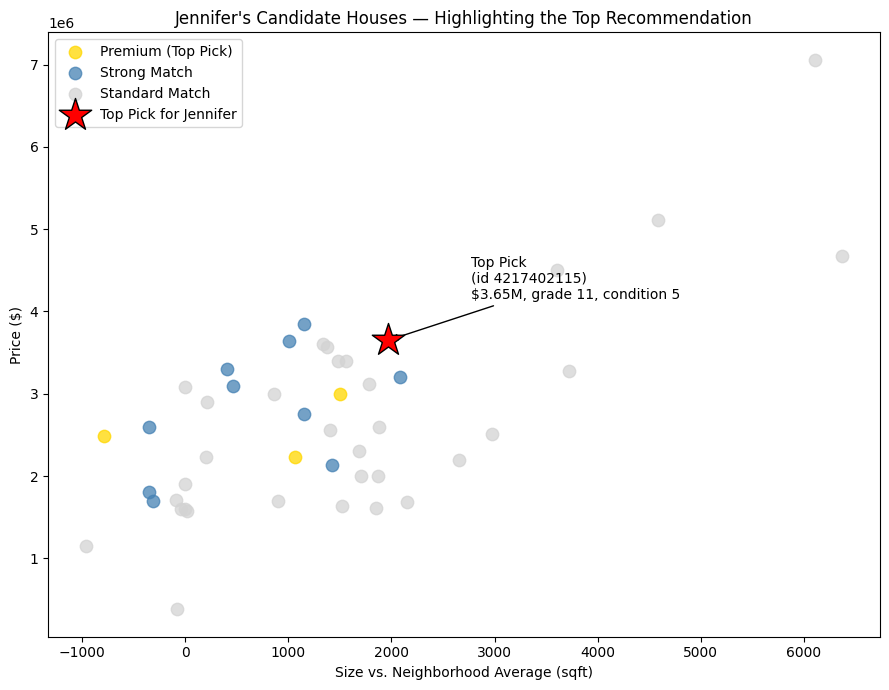

In [270]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

tier_colors = {"Premium (Top Pick)": "gold", "Strong Match": "steelblue", "Standard Match": "lightgray"}
for tier, color in tier_colors.items():
    subset = jennifer_clean[jennifer_clean["quality_tier"] == tier]
    ax.scatter(subset["living_vs_neighbors"], subset["price"], c=color, label=tier, alpha=0.75, s=80)

top_pick = jennifer_clean[jennifer_clean["id"] == 4217402115]
ax.scatter(
    top_pick["living_vs_neighbors"], top_pick["price"],
    c="red", marker="*", s=600, label="Top Pick for Jennifer",
    edgecolors="black", zorder=5
)
ax.annotate(
    "Top Pick\n(id 4217402115)\n$3.65M, grade 11, condition 5",
    xy=(top_pick["living_vs_neighbors"].values[0], top_pick["price"].values[0]),
    xytext=(top_pick["living_vs_neighbors"].values[0] + 800, top_pick["price"].values[0] + 500000),
    arrowprops=dict(arrowstyle="->", color="black")
)

ax.set_xlabel("Size vs. Neighborhood Average (sqft)")
ax.set_ylabel("Price ($)")
ax.set_title("Jennifer's Candidate Houses — Highlighting the Top Recommendation")
ax.legend()
plt.tight_layout()
plt.savefig("jennifer_top_pick_highlight.png", dpi=150, bbox_inches="tight")
plt.show()

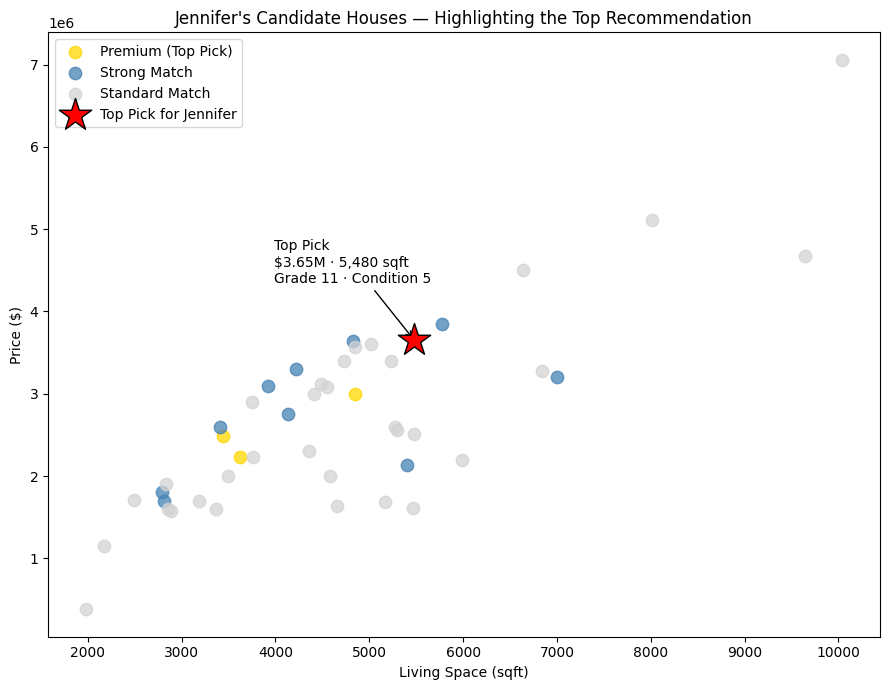

In [271]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

tier_colors = {"Premium (Top Pick)": "gold", "Strong Match": "steelblue", "Standard Match": "lightgray"}
for tier, color in tier_colors.items():
    subset = jennifer_clean[jennifer_clean["quality_tier"] == tier]
    ax.scatter(subset["sqft_living"], subset["price"], c=color, label=tier, alpha=0.75, s=80)

top_pick = jennifer_clean[jennifer_clean["id"] == 4217402115]
ax.scatter(
    top_pick["sqft_living"], top_pick["price"],
    c="red", marker="*", s=600, label="Top Pick for Jennifer",
    edgecolors="black", zorder=5
)
ax.annotate(
    "Top Pick\n$3.65M · 5,480 sqft\nGrade 11 · Condition 5",
    xy=(top_pick["sqft_living"].values[0], top_pick["price"].values[0]),
    xytext=(top_pick["sqft_living"].values[0] - 1500, top_pick["price"].values[0] + 700000),
    arrowprops=dict(arrowstyle="->", color="black")
)

ax.set_xlabel("Living Space (sqft)")
ax.set_ylabel("Price ($)")
ax.set_title("Jennifer's Candidate Houses — Highlighting the Top Recommendation")
ax.legend()
plt.tight_layout()
plt.savefig("jennifer_top_pick_highlight_simple.png", dpi=150, bbox_inches="tight")
plt.show()

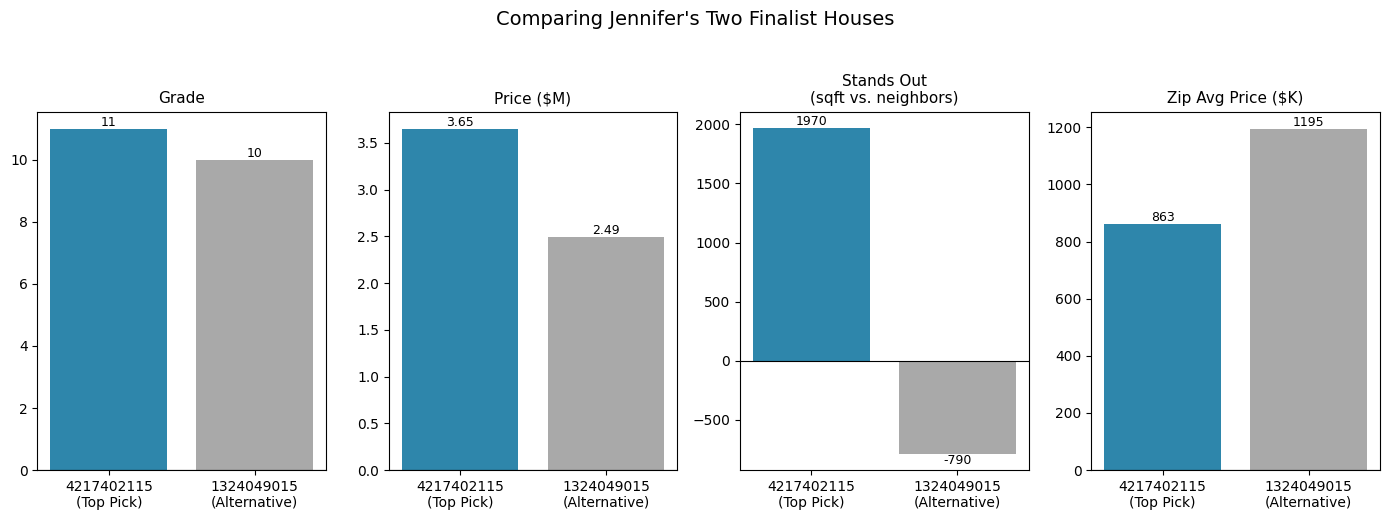

In [272]:
import matplotlib.pyplot as plt

houses = ["4217402115\n(Top Pick)", "1324049015\n(Alternative)"]
colors = ["#2E86AB", "#A9A9A9"]

criteria = {
    "Grade": [11, 10],
    "Price ($M)": [3.65, 2.49],
    "Stands Out\n(sqft vs. neighbors)": [1970, -790],
    "Zip Avg Price ($K)": [863, 1195],
}

fig, axes = plt.subplots(1, 4, figsize=(14, 5))
for ax, (label, values) in zip(axes, criteria.items()):
    bars = ax.bar(houses, values, color=colors)
    ax.set_title(label, fontsize=11)
    ax.axhline(0, color="black", linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.annotate(f"{val}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha="center", va="bottom" if val >= 0 else "top", fontsize=9)

fig.suptitle("Comparing Jennifer's Two Finalist Houses", fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("jennifer_finalist_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [273]:
quality_rank_map = {"Premium (Top Pick)": 3, "Strong Match": 2, "Standard Match": 1}
location_rank_map = {"Prestige Location": 3, "Mid-Tier Location": 2, "Modest Location": 1}

jennifer_clean["match_score"] = (
    jennifer_clean["quality_tier"].map(quality_rank_map) * 10 +
    jennifer_clean["location_tier"].map(location_rank_map) * 10 +
    (jennifer_clean["grade"] - jennifer_clean["grade"].min()) * 5 +
    (jennifer_clean["living_vs_neighbors"] > 0).astype(int) * 10
)

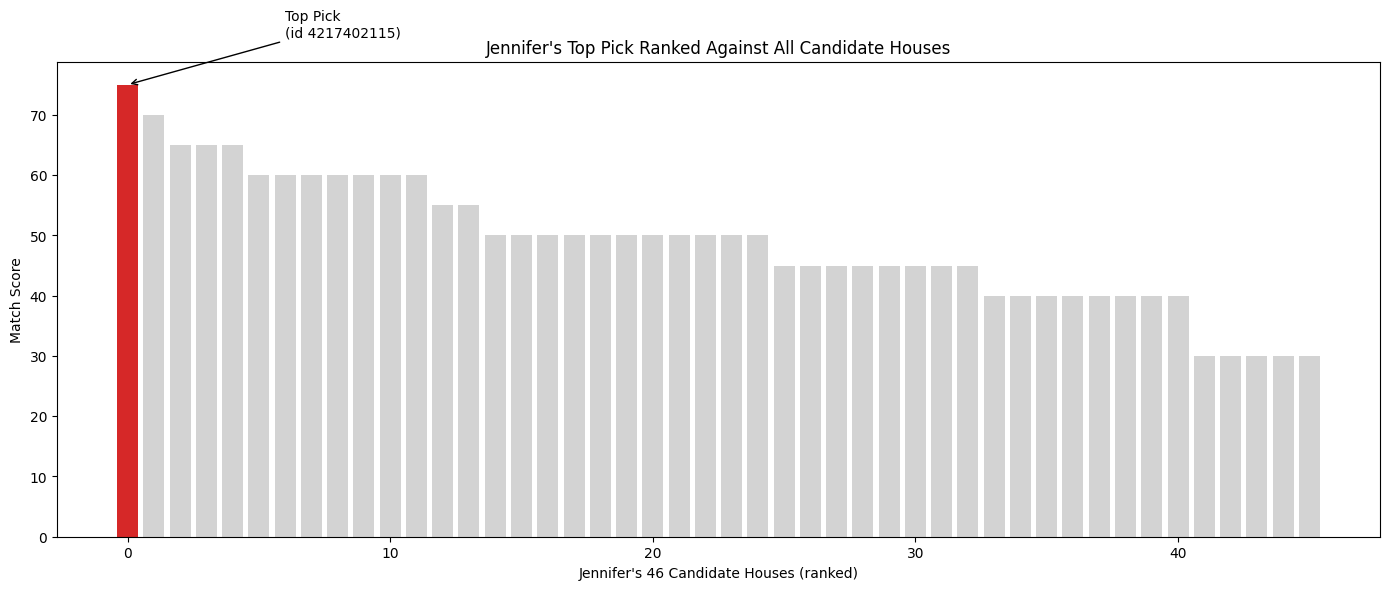

In [274]:
sorted_houses = jennifer_clean.sort_values("match_score", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ["#D62828" if id_ == 4217402115 else "lightgray" for id_ in sorted_houses["id"]]
ax.bar(range(len(sorted_houses)), sorted_houses["match_score"], color=colors)
ax.set_xlabel("Jennifer's 46 Candidate Houses (ranked)")
ax.set_ylabel("Match Score")
ax.set_title("Jennifer's Top Pick Ranked Against All Candidate Houses")

top_idx = sorted_houses[sorted_houses["id"] == 4217402115].index[0]
ax.annotate(
    "Top Pick\n(id 4217402115)",
    xy=(top_idx, sorted_houses.loc[top_idx, "match_score"]),
    xytext=(top_idx + 6, sorted_houses.loc[top_idx, "match_score"] + 8),
    arrowprops=dict(arrowstyle="->", color="black")
)
plt.tight_layout()
plt.savefig("jennifer_ranked_all_houses.png", dpi=150, bbox_inches="tight")
plt.show()

In [275]:
top_pick = jennifer_clean[jennifer_clean["id"] == 4217402115]
top_pick.T

,10495
id,4217402115
bedrooms,6
bathrooms,4.75
sqft_living,5480
sqft_lot,19401
floors,1.5
waterfront,1.0
view,4.0
condition,5
grade,11


In [276]:
top_pick[
    ["id", "price", "grade", "condition", "waterfront", "zipcode",
     "location_tier", "quality_tier", "living_vs_neighbors", "lot_vs_neighbors",
     "zip_avg_price", "price_vs_zip_avg", "yr_renovated", "house_age_at_sale", "match_score"]
].T

,10495
id,4217402115
price,3650000.0
grade,11
condition,5
waterfront,1.0
zipcode,98105
location_tier,Prestige Location
quality_tier,Premium (Top Pick)
living_vs_neighbors,1970
lot_vs_neighbors,3591


In [277]:
top_pick_values = jennifer_clean[jennifer_clean["id"] == 4217402115].iloc[0]

metrics = ["price", "sqft_living", "grade", "condition", "sqft_lot"]

comparison = pd.DataFrame({
    "value": [top_pick_values[m] for m in metrics],
    "percentile_vs_county": [(df[m] < top_pick_values[m]).mean() * 100 for m in metrics],
    "percentile_vs_jennifer_list": [(jennifer_clean[m] < top_pick_values[m]).mean() * 100 for m in metrics],
}, index=metrics)

comparison

,value,percentile_vs_county,percentile_vs_jennifer_list
price,3650000.0,99.915966,86.956522
sqft_living,5480.0,99.411765,78.260870
grade,11.0,97.679739,54.347826
condition,5.0,92.124183,91.304348
sqft_lot,19401.0,88.888889,54.347826


### Top Pick — How It Compares
Comparing id 4217402115 against both the full King County market and Jennifer's own
46-house shortlist confirms it as an exceptional, well-rounded choice:

- **Price:** Top 0.1% of King County (99.9th percentile); beats 87% of Jennifer's own shortlist
- **Size (sqft_living):** Top 0.6% countywide (99.4th percentile); beats 78% of her shortlist
- **Grade:** Top 2.3% countywide (97.7th percentile); mid-pack within her shortlist (54th percentile),
  since grade only ranges 10–12 across her already-filtered candidates
- **Condition:** Top 7.9% countywide (92.1st percentile); beats 91% of her shortlist —
  a standout even among already-excellent houses
- **Lot size:** Top 11% countywide (88.9th percentile); mid-pack within her shortlist (54th percentile)

**Takeaway:** This house isn't simply good because it belongs to an already-elite segment —
it stands out even when compared only to Jennifer's other top candidates, particularly on
price, size, and condition, the three factors most central to her wishes.

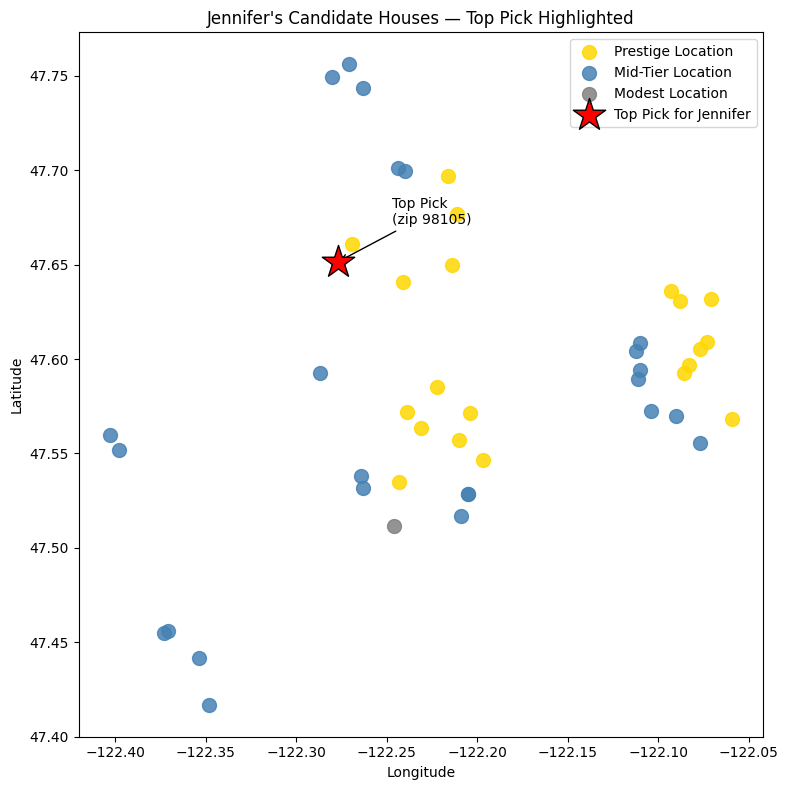

In [278]:
colors = {"Prestige Location": "gold", "Mid-Tier Location": "steelblue", "Modest Location": "gray"}

fig, ax = plt.subplots(figsize=(8, 8))
for tier, color in colors.items():
    subset = jennifer_clean[jennifer_clean["location_tier"] == tier]
    ax.scatter(subset["long"], subset["lat"], c=color, label=tier, alpha=0.85, s=100)

top_pick = jennifer_clean[jennifer_clean["id"] == 4217402115]
ax.scatter(
    top_pick["long"], top_pick["lat"],
    c="red", marker="*", s=600, label="Top Pick for Jennifer",
    edgecolors="black", zorder=5
)
ax.annotate(
    "Top Pick\n(zip 98105)",
    xy=(top_pick["long"].values[0], top_pick["lat"].values[0]),
    xytext=(top_pick["long"].values[0] + 0.03, top_pick["lat"].values[0] + 0.02),
    arrowprops=dict(arrowstyle="->", color="black")
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Jennifer's Candidate Houses — Top Pick Highlighted")
ax.legend()
plt.tight_layout()
plt.savefig("jennifer_location_map_with_top_pick.png", dpi=150, bbox_inches="tight")
plt.show()

In [279]:
top_pick_values = jennifer_clean[jennifer_clean["id"] == 4217402115].iloc[0]

metrics = ["price", "sqft_living", "sqft_lot", "sqft_above", "sqft_basement",
           "bedrooms", "bathrooms", "floors", "view", "condition", "grade",
           "sqft_living15", "sqft_lot15"]

comparison_full = pd.DataFrame({
    "value": [top_pick_values[m] for m in metrics],
    "percentile_vs_county": [(df[m] < top_pick_values[m]).mean() * 100 for m in metrics],
}, index=metrics)

comparison_full

,value,percentile_vs_county
price,3650000.00,99.915966
sqft_living,5480.00,99.411765
sqft_lot,19401.00,88.888889
sqft_above,3910.00,97.754435
sqft_basement,1570.00,96.521942
bedrooms,6.00,98.478058
bathrooms,4.75,99.593838
floors,1.50,49.262372
view,4.00,98.239963
condition,5.00,92.124183


In [280]:
core_cols = ["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot",
             "floors", "waterfront", "view", "condition", "grade", "yr_built"]

df[core_cols].describe().T[["mean", "50%", "min", "max"]].rename(columns={"50%": "median"})

,mean,median,min,max
price,541861.428151,450550.00,78000.0,7700000.0
bedrooms,3.372549,3.00,1.0,11.0
bathrooms,2.118429,2.25,0.5,8.0
sqft_living,2083.132633,1920.00,370.0,13540.0
sqft_lot,15128.038002,7614.00,520.0,1651359.0
floors,1.495985,1.50,1.0,3.5
waterfront,0.007660,0.00,0.0,1.0
view,0.234677,0.00,0.0,4.0
condition,3.410784,3.00,1.0,5.0
grade,7.662792,7.00,3.0,13.0


In [281]:
top_pick_values = jennifer_clean[jennifer_clean["id"] == 4217402115].iloc[0]

comparison = pd.DataFrame({
    "her_house": [top_pick_values[c] for c in core_cols],
    "county_average": [df[c].mean() for c in core_cols],
    "percentile_vs_county": [(df[c] < top_pick_values[c]).mean() * 100 for c in core_cols],
}, index=core_cols)

comparison

,her_house,county_average,percentile_vs_county
price,3650000.00,541861.428151,99.915966
bedrooms,6.00,3.372549,98.478058
bathrooms,4.75,2.118429,99.593838
sqft_living,5480.00,2083.132633,99.411765
sqft_lot,19401.00,15128.038002,88.888889
floors,1.50,1.495985,49.262372
waterfront,1.00,0.007660,88.300654
view,4.00,0.234677,98.239963
condition,5.00,3.410784,92.124183
grade,11.00,7.662792,97.679739


In [282]:
core_cols = [
    "price", "bedrooms", "bathrooms",
    "sqft_living", "sqft_lot", "sqft_above", "sqft_basement",
    "floors", "waterfront", "view", "condition", "grade",
    "yr_built", "yr_renovated",
    "sqft_living15", "sqft_lot15"
]

In [283]:
df[core_cols].describe().T[["mean", "50%", "min", "max"]].rename(columns={"50%": "median"})

,mean,median,min,max
price,541861.428151,450550.00,78000.0,7700000.0
bedrooms,3.372549,3.00,1.0,11.0
bathrooms,2.118429,2.25,0.5,8.0
sqft_living,2083.132633,1920.00,370.0,13540.0
sqft_lot,15128.038002,7614.00,520.0,1651359.0
sqft_above,1791.170215,1560.00,370.0,9410.0
sqft_basement,292.086938,0.00,0.0,4820.0
floors,1.495985,1.50,1.0,3.5
waterfront,0.007660,0.00,0.0,1.0
view,0.234677,0.00,0.0,4.0


In [284]:
top_pick_values = jennifer_clean[jennifer_clean["id"] == 4217402115].iloc[0]

comparison = pd.DataFrame({
    "her_house": [top_pick_values[c] for c in core_cols],
    "county_average": [df[c].mean() for c in core_cols],
    "percentile_vs_county": [(df[c] < top_pick_values[c]).mean() * 100 for c in core_cols],
}, index=core_cols)

comparison

,her_house,county_average,percentile_vs_county
price,3650000.00,541861.428151,99.915966
bedrooms,6.00,3.372549,98.478058
bathrooms,4.75,2.118429,99.593838
sqft_living,5480.00,2083.132633,99.411765
sqft_lot,19401.00,15128.038002,88.888889
sqft_above,3910.00,1791.170215,97.754435
sqft_basement,1570.00,292.086938,96.521942
floors,1.50,1.495985,49.262372
waterfront,1.00,0.007660,88.300654
view,4.00,0.234677,98.239963


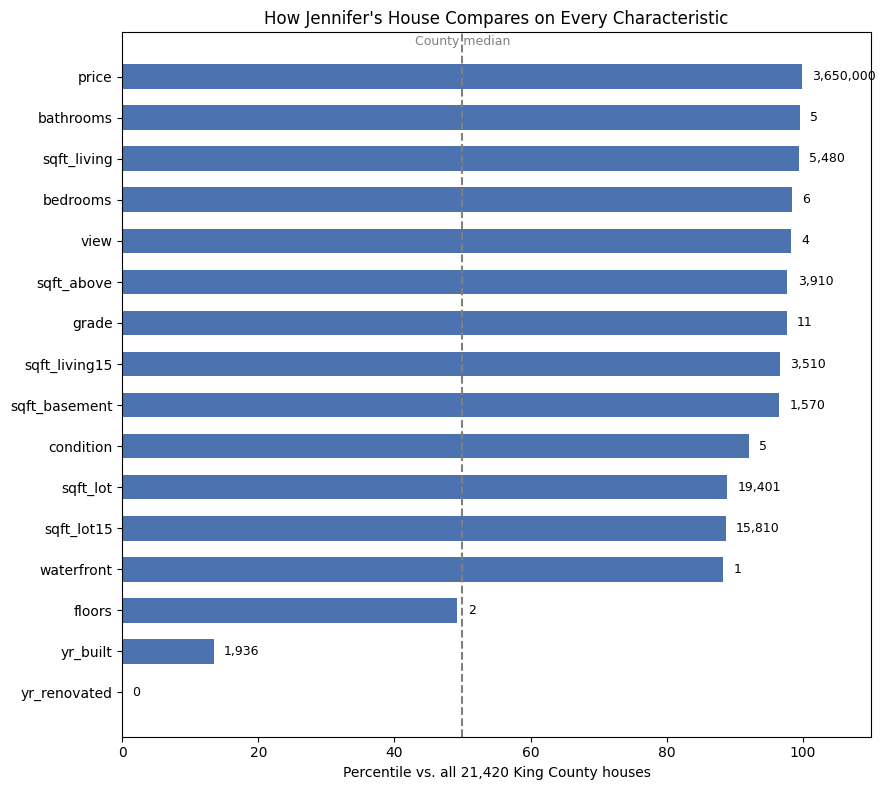

In [285]:
import matplotlib.pyplot as plt

# Sort by percentile so the strongest characteristics are at the top
comparison_sorted = comparison.sort_values("percentile_vs_county", ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))

bars = ax.barh(comparison_sorted.index, comparison_sorted["percentile_vs_county"],
                color="#4C72B0", height=0.6)

# Reference line at the county median (50th percentile)
ax.axvline(50, color="gray", linestyle="--", linewidth=1.5)
ax.text(50, len(comparison_sorted) - 0.3, "County median", color="gray",
        ha="center", va="bottom", fontsize=9)

# Label each bar with the actual value, so the audience sees real numbers too
for bar, value in zip(bars, comparison_sorted["her_house"]):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f"{value:,.0f}", va="center", fontsize=9)

ax.set_xlim(0, 110)
ax.set_xlabel("Percentile vs. all 21,420 King County houses")
ax.set_title("How Jennifer's House Compares on Every Characteristic")

plt.tight_layout()
plt.show()

Hypothesis 1 — waterfront + high-grade houses cluster in a small number of top-ranked zip codes

In [286]:
segment = df[(df["waterfront"] == 1) & (df["grade"] >= 10)]

print("Qualifying houses:", len(segment))
print("Unique zip codes among them:", segment["zipcode"].nunique())
print("Total zip codes in the county:", df["zipcode"].nunique())

zip_counts = segment["zipcode"].value_counts()
top5_share = zip_counts.head(5).sum() / zip_counts.sum() * 100
print(f"Top 5 zip codes hold {top5_share:.1f}% of all waterfront+high-grade houses")

Qualifying houses: 57
Unique zip codes among them: 23
Total zip codes in the county: 70
Top 5 zip codes hold 47.4% of all waterfront+high-grade houses


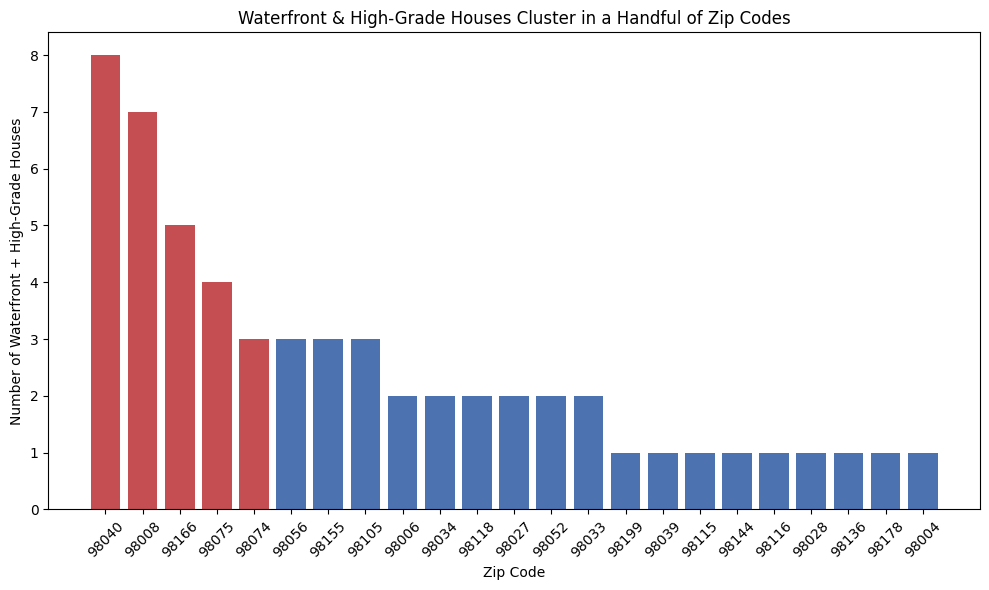

In [287]:
import matplotlib.pyplot as plt

zip_counts_sorted = zip_counts.sort_values(ascending=False)
colors = ["#C44E52" if i < 5 else "#4C72B0" for i in range(len(zip_counts_sorted))]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(zip_counts_sorted.index.astype(str), zip_counts_sorted.values, color=colors)
ax.set_xlabel("Zip Code")
ax.set_ylabel("Number of Waterfront + High-Grade Houses")
ax.set_title("Waterfront & High-Grade Houses Cluster in a Handful of Zip Codes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

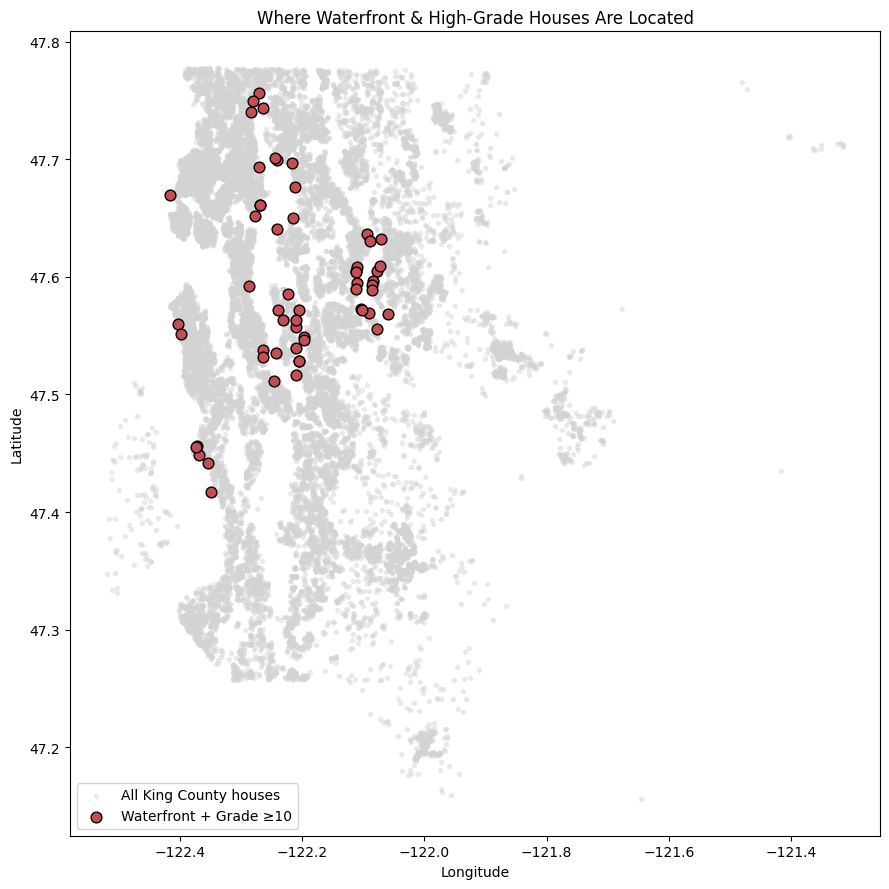

In [288]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(df["long"], df["lat"], c="lightgray", s=8, alpha=0.4, label="All King County houses")
ax.scatter(segment["long"], segment["lat"], c="#C44E52", s=60, edgecolor="black", label="Waterfront + Grade ≥10")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Where Waterfront & High-Grade Houses Are Located")
ax.legend()
plt.tight_layout()
plt.show()

Hypothesis 2 — waterfront+high-grade sells well above county median; renovation adds a separate premium

In [289]:
# Part A: the segment premium
segment_median = segment["price"].median()
county_median = df["price"].median()
premium_pct = (segment_median - county_median) / county_median * 100
print(f"Segment median: {segment_median:,.0f} | County median: {county_median:,.0f} | Premium: {premium_pct:.1f}%")

Segment median: 2,510,000 | County median: 450,550 | Premium: 457.1%


In [290]:
# Part B: renovation premium, tested on the BROADER market, not just the segment
renovated = df[df["yr_renovated"] > 0]
not_renovated = df[df["yr_renovated"] == 0]

renov_median = renovated["price"].median()
not_renov_median = not_renovated["price"].median()
renov_premium_pct = (renov_median - not_renov_median) / not_renov_median * 100
print(f"Renovated median: {renov_median:,.0f} | Not renovated median: {not_renov_median:,.0f} | Premium: {renov_premium_pct:.1f}%")

Renovated median: 612,200 | Not renovated median: 449,950 | Premium: 36.1%


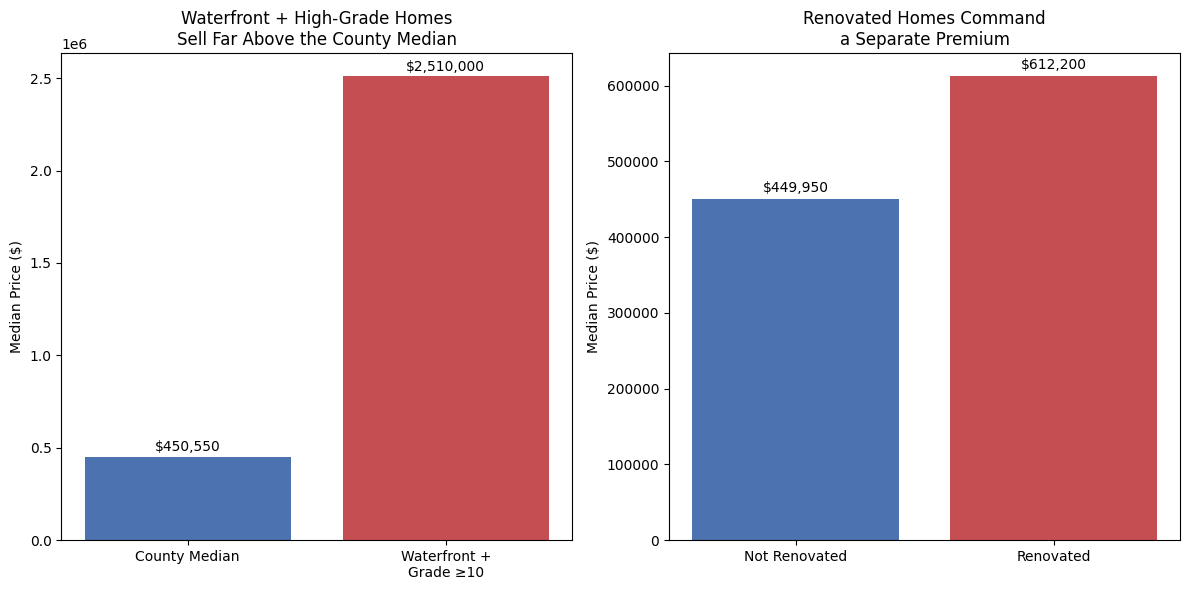

In [291]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Panel 1: the segment premium
axes[0].bar(["County Median", "Waterfront +\nGrade ≥10"], [county_median, segment_median],
            color=["#4C72B0", "#C44E52"])
axes[0].set_ylabel("Median Price ($)")
axes[0].set_title("Waterfront + High-Grade Homes\nSell Far Above the County Median")
for i, v in enumerate([county_median, segment_median]):
    axes[0].text(i, v + 30000, f"${v:,.0f}", ha="center")

# Panel 2: the renovation premium
axes[1].bar(["Not Renovated", "Renovated"], [not_renov_median, renov_median],
            color=["#4C72B0", "#C44E52"])
axes[1].set_ylabel("Median Price ($)")
axes[1].set_title("Renovated Homes Command\na Separate Premium")
for i, v in enumerate([not_renov_median, renov_median]):
    axes[1].text(i, v + 10000, f"${v:,.0f}", ha="center")

plt.tight_layout()
plt.show()

In [292]:
df.groupby(df["yr_renovated"] > 0)["condition"].mean()

yr_renovated
False    3.417650
True     3.218919
Name: condition, dtype: float64

In [293]:
condition_premium = df.groupby(["condition", df["yr_renovated"] > 0])["price"].median().unstack()
condition_premium.columns = ["Not Renovated", "Renovated"]
condition_premium["Premium (%)"] = (
    (condition_premium["Renovated"] - condition_premium["Not Renovated"])
    / condition_premium["Not Renovated"] * 100
)
condition_premium

,Not Renovated,Renovated,Premium (%)
condition,,,
1,295000.0,252000.0,-14.576271
2,280000.0,250000.0,-10.714286
3,450000.0,625000.0,38.888889
4,439725.0,600000.0,36.448917
5,526750.0,733000.0,39.155197


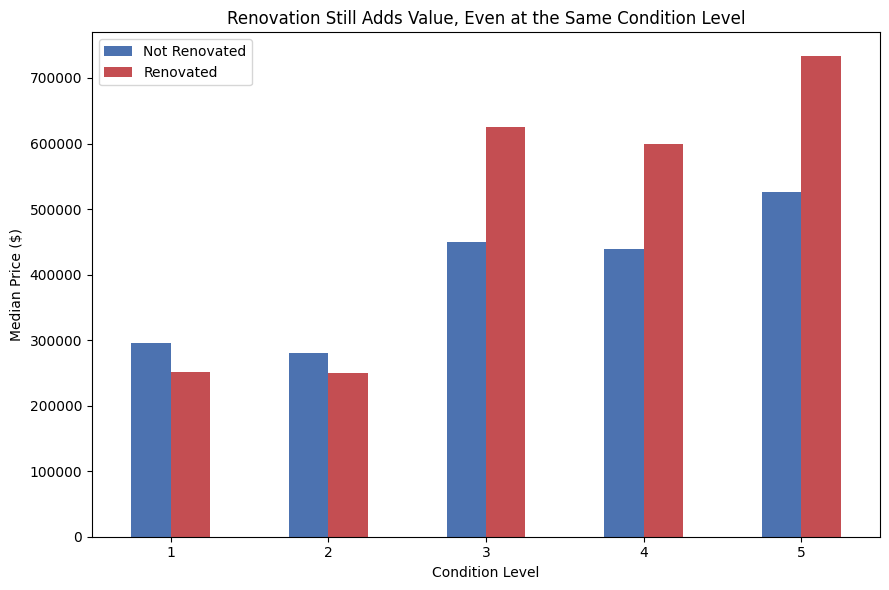

In [294]:
condition_price = df.groupby(["condition", df["yr_renovated"] > 0])["price"].median().unstack()
condition_price.columns = ["Not Renovated", "Renovated"]

fig, ax = plt.subplots(figsize=(9, 6))
condition_price.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xlabel("Condition Level")
ax.set_ylabel("Median Price ($)")
ax.set_title("Renovation Still Adds Value, Even at the Same Condition Level")
ax.legend(title="")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Hypothesis 3 — resold-within-1-year houses show positive appreciation on average

In [295]:
resold = df[df["num_sales"] > 1].copy()
resold[["gap_days", "price_change", "pct_change"]] = resold.apply(compute_gap_and_change, axis=1)

within_year = resold[resold["gap_days"] <= 365]

print("Houses resold within ~1 year:", len(within_year))
print("Average % price change:", within_year["pct_change"].mean())
print("Median % price change:", within_year["pct_change"].median())
print("Share with positive appreciation:", (within_year["pct_change"] > 0).mean() * 100, "%")

Houses resold within ~1 year: 176
Average % price change: 56.7694368908964
Median % price change: 54.43322109988776
Share with positive appreciation: 94.88636363636364 %


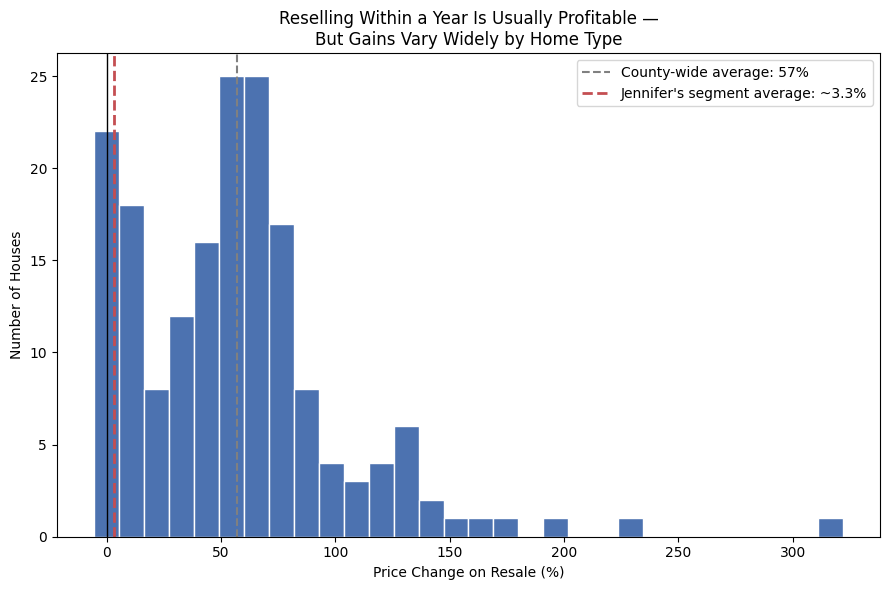

In [296]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(within_year["pct_change"], bins=30, color="#4C72B0", edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.axvline(within_year["pct_change"].mean(), color="gray", linestyle="--",
           label=f"County-wide average: {within_year['pct_change'].mean():.0f}%")
ax.axvline(3.3, color="#C44E52", linestyle="--", linewidth=2,
           label="Jennifer's segment average: ~3.3%")
ax.set_xlabel("Price Change on Resale (%)")
ax.set_ylabel("Number of Houses")
ax.set_title("Reselling Within a Year Is Usually Profitable —\nBut Gains Vary Widely by Home Type")
ax.legend()
plt.tight_layout()
plt.show()

In [297]:
total = len(df)
print(f"Total houses: {total}")

# 1. Waterfront
n_waterfront = df[df['waterfront'] == 1]['id'].nunique()
print(f"Waterfront: {n_waterfront}")

# 2. High grade (>= 10 — same threshold used elsewhere in the deck)
n_high_grade = df[df['grade'] >= 10]['id'].nunique()
print(f"High grade (>=10): {n_high_grade}")

# 3. Renovated (yr_renovated not 0 / not blank)
n_renovated = df[df['yr_renovated'] > 0]['id'].nunique()
print(f"Renovated: {n_renovated}")

# 4. Resell within 1 year (has a matching repeat sale within ~365 days)
df['date'] = pd.to_datetime(df['date'])  # skip if already datetime

repeat_ids = []
for house_id, dates in df.groupby('id')['date'].apply(list).items():
    if len(dates) > 1:
        dates_sorted = sorted(dates)
        if any((dates_sorted[i+1] - dates_sorted[i]).days <= 365 for i in range(len(dates_sorted) - 1)):
            repeat_ids.append(house_id)

n_resell_1yr = len(repeat_ids)
print(f"Resell within 1 year: {n_resell_1yr}")

Total houses: 21420
Waterfront: 146
High grade (>=10): 1627
Renovated: 740
Resell within 1 year: 0


In [298]:
print(len(df), df['id'].nunique())

21420 21420


In [301]:
import os
print(os.getcwd())
for root, dirs, files in os.walk('.'):
    for f in files:
        if f.endswith('.csv'):
            print(os.path.join(root, f))

/Users/zina/Documents/GitHub/ds-eda-project_zb
./.venv/lib/python3.13/site-packages/numpy/_core/tests/data/umath-validation-set-log2.csv
./.venv/lib/python3.13/site-packages/numpy/_core/tests/data/umath-validation-set-arcsinh.csv
./.venv/lib/python3.13/site-packages/numpy/_core/tests/data/umath-validation-set-arctanh.csv
./.venv/lib/python3.13/site-packages/numpy/_core/tests/data/umath-validation-set-sin.csv
./.venv/lib/python3.13/site-packages/numpy/_core/tests/data/umath-validation-set-cos.csv
./.venv/lib/python3.13/site-packages/numpy/_core/tests/data/umath-validation-set-cbrt.csv
./.venv/lib/python3.13/site-packages/numpy/_core/tests/data/umath-validation-set-arctan.csv
./.venv/lib/python3.13/site-packages/numpy/_core/tests/data/umath-validation-set-cosh.csv
./.venv/lib/python3.13/site-packages/numpy/_core/tests/data/umath-validation-set-expm1.csv
./.venv/lib/python3.13/site-packages/numpy/_core/tests/data/umath-validation-set-sinh.csv
./.venv/lib/python3.13/site-packages/numpy/_co

In [302]:
raw = pd.read_csv('./data/kc_house_data_full.csv')  # your original filename
print(len(raw), raw['id'].nunique())

21420 21420


In [303]:
summary = pd.DataFrame({
    'Wish': ['Waterfront', 'High grade (>=10)', 'Renovated'],
    'Houses matching': [n_waterfront, n_high_grade, n_renovated],
})
summary['% of all 21,420'] = (summary['Houses matching'] / total * 100).round(1)
summary = summary.sort_values('Houses matching', ascending=False).reset_index(drop=True)
summary

,Wish,Houses matching,"% of all 21,420"
0,High grade (>=10),1627,7.6
1,Renovated,740,3.5
2,Waterfront,146,0.7


In [305]:
price_90th = df['price'].quantile(0.90)
n_high_budget = df[df['price'] >= price_90th]['id'].nunique()
print(f"High budget (top 10%, price >= ${price_90th:,.0f}): {n_high_budget}")

High budget (top 10%, price >= $889,000): 2145


In [306]:
n_all = df[
    (df['waterfront'] == 1) &
    (df['grade'] >= 10) &
    (df['yr_renovated'] > 0) &
    (df['price'] >= price_90th)
]['id'].nunique()
print(f"All four together: {n_all}")

All four together: 6


In [308]:
mask = (
    (df['waterfront'] == 1) &
    (df['grade'] >= 10) &
    (df['yr_renovated'] > 0) &
    (df['price'] >= price_90th)
)
pd.set_option('display.max_columns', None)  # so nothing gets truncated
df.loc[mask].sort_values('price', ascending=False)

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,num_sales,sale_dates,sale_prices,sqft_per_bedroom,sqft_check
21208,9808700762,5,4.50,10040,37325,2.0,1.0,2.0,3,11,7680,2360.0,1940,2001.0,98004,47.6500,-122.214,3930,25449,2014-06-11,7060000.0,1,[2014-06-11],[7060000.0],2008.000000,0.0
3002,1924059029,5,6.75,9640,13068,1.0,1.0,4.0,3,12,4820,4820.0,1983,2009.0,98040,47.5570,-122.210,3270,10454,2014-06-17,4670000.0,1,[2014-06-17],[4670000.0],1928.000000,0.0
10152,4114601570,3,3.25,5020,12431,2.0,1.0,4.0,3,10,3420,1600.0,1941,2002.0,98144,47.5925,-122.287,3680,12620,2014-11-18,3600000.0,1,[2014-11-18],[3600000.0],1673.333333,0.0
8460,3625059152,3,3.25,4220,41300,1.0,1.0,4.0,4,11,2460,1760.0,1958,1987.0,98008,47.6083,-122.110,3810,30401,2014-12-30,3300000.0,1,[2014-12-30],[3300000.0],1406.666667,0.0
7624,3343302110,3,3.00,2790,13295,2.0,1.0,4.0,4,10,2370,420.0,1933,1989.0,98006,47.5466,-122.197,3140,11949,2015-03-06,1800000.0,1,[2015-03-06],[1800000.0],930.000000,0.0
13090,6117502230,3,3.50,4660,21164,2.0,1.0,4.0,3,12,4660,0.0,1975,1990.0,98166,47.4418,-122.354,3140,24274,2014-12-01,1640000.0,1,[2014-12-01],[1640000.0],1553.333333,0.0


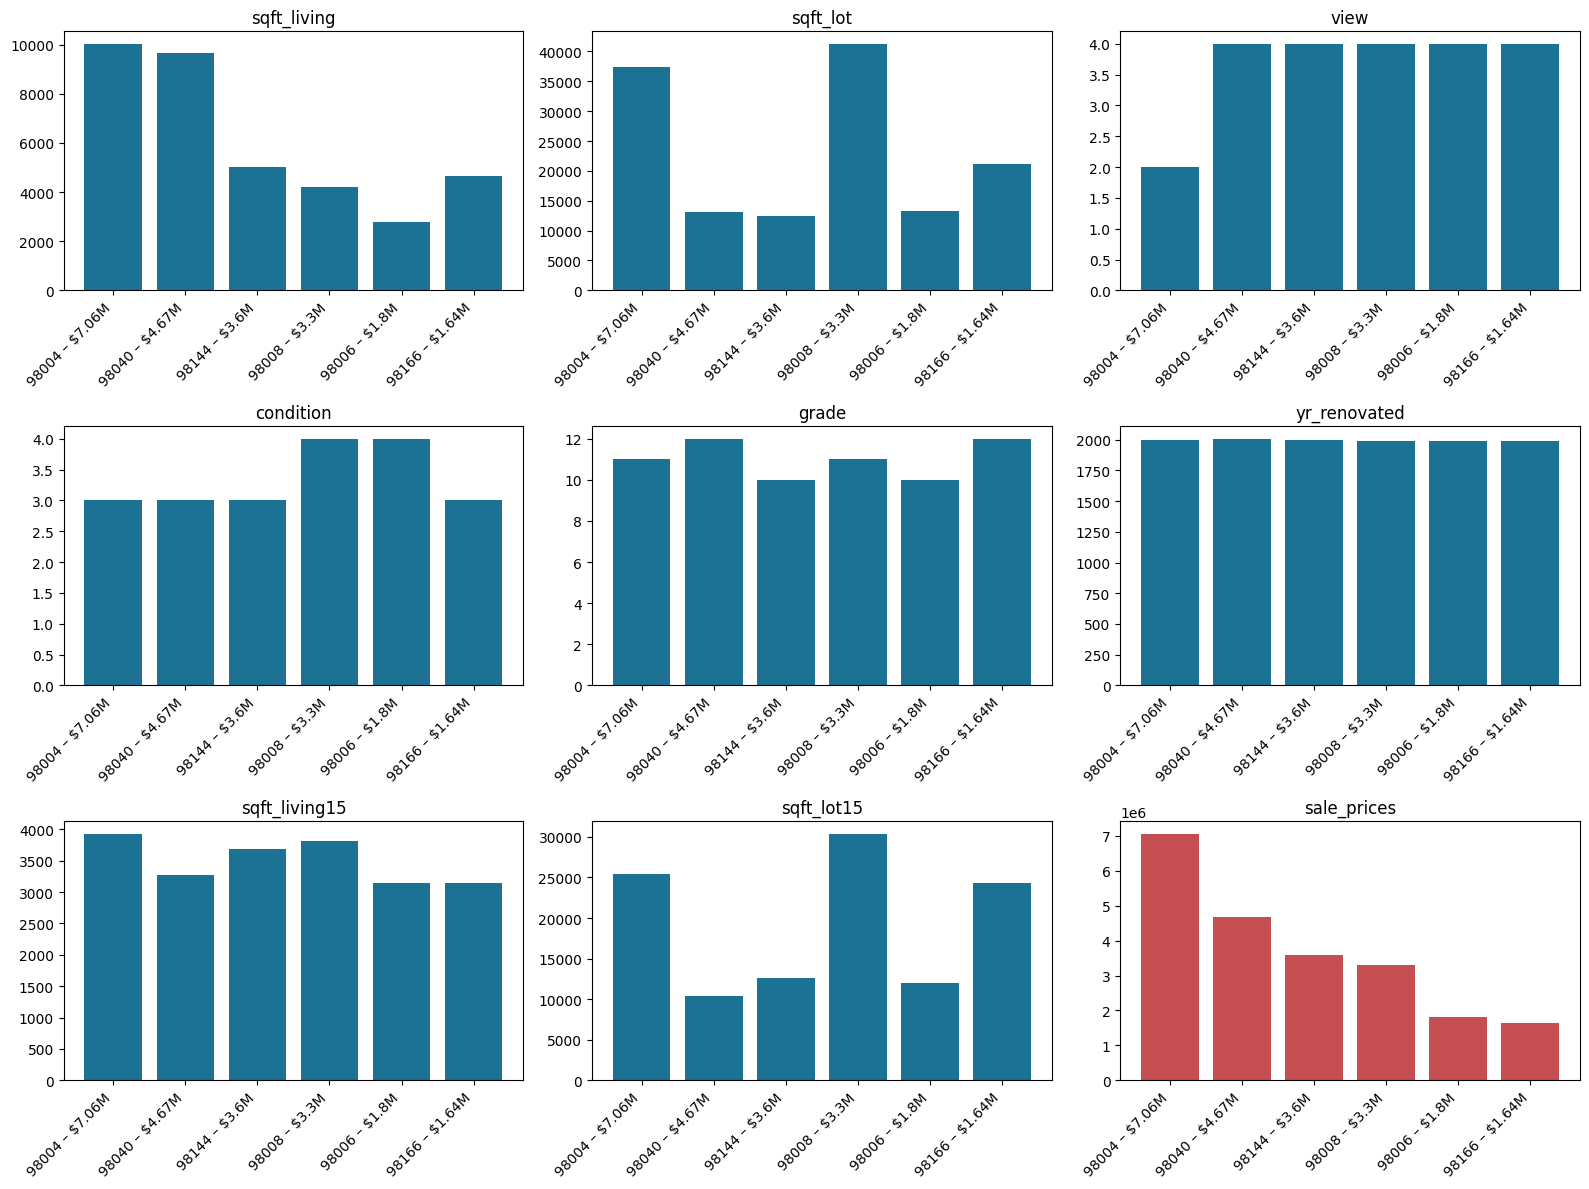

In [309]:
import matplotlib.pyplot as plt

subset = df.loc[mask].sort_values('price', ascending=False).reset_index(drop=True)
labels = subset['zipcode'].astype(str) + " – $" + (subset['price'] / 1e6).round(2).astype(str) + "M"

features = ['sqft_living', 'sqft_lot', 'view', 'condition',
            'grade', 'yr_renovated', 'sqft_living15', 'sqft_lot15']
sale_price = subset['sale_prices'].apply(lambda x: x[0] if isinstance(x, list) else x)

TEAL = '#1C7293'
CORAL = '#C44E52'

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    ax.bar(labels, subset[feat], color=TEAL)
    ax.set_title(feat)
    ax.tick_params(axis='x', rotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha('right')

ax = axes[8]
ax.bar(labels, sale_price, color=CORAL)
ax.set_title('sale_prices')
ax.tick_params(axis='x', rotation=45)
for lbl in ax.get_xticklabels():
    lbl.set_ha('right')

plt.tight_layout()
plt.savefig('renovated_finalists_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

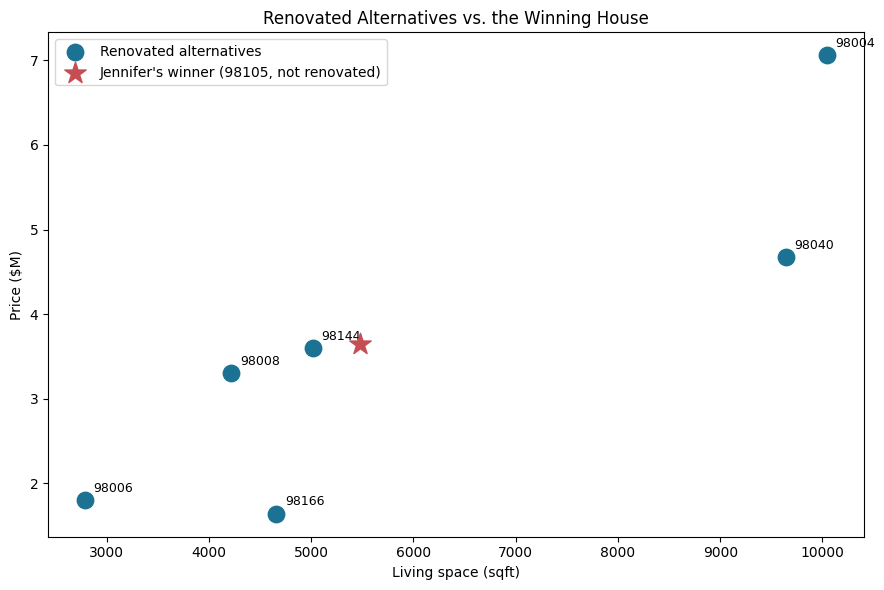

In [310]:
import matplotlib.pyplot as plt

winner = df[df['id'] == 4217402115]  # Jennifer's winning house

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(subset['sqft_living'], subset['price'] / 1e6, s=140,
           color='#1C7293', label='Renovated alternatives', zorder=2)
for _, row in subset.iterrows():
    ax.annotate(str(row['zipcode']), (row['sqft_living'], row['price'] / 1e6),
                textcoords="offset points", xytext=(6, 6), fontsize=9)

ax.scatter(winner['sqft_living'], winner['price'] / 1e6, s=260,
           color='#C44E52', marker='*', label="Jennifer's winner (98105, not renovated)", zorder=3)

ax.set_xlabel('Living space (sqft)')
ax.set_ylabel('Price ($M)')
ax.set_title('Renovated Alternatives vs. the Winning House')
ax.legend()
plt.tight_layout()
plt.savefig('renovated_vs_winner.png', dpi=150, bbox_inches='tight')
plt.show()

In [312]:
print(df.columns.tolist())

['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'date', 'price', 'num_sales', 'sale_dates', 'sale_prices', 'sqft_per_bedroom', 'sqft_check']


In [313]:
# Big house — top 10% by living space, same logic as the "high budget" price cut
sqft_90th = df['sqft_living'].quantile(0.90)
n_big_house = df[df['sqft_living'] >= sqft_90th]['id'].nunique()

# High-price area — zip codes whose median price sits in the top 10% county-wide
zip_median_price = df.groupby('zipcode')['price'].median()
prestige_zips = zip_median_price[zip_median_price >= zip_median_price.quantile(0.90)].index
n_prestige_area = df[df['zipcode'].isin(prestige_zips)]['id'].nunique()

# Bigger than neighbors — sqft_living15 is King County's own field for the
# average living space of the 15 nearest neighbors, so this is a direct comparison
n_bigger_than_neighbors = df[df['sqft_living'] > df['sqft_living15']]['id'].nunique()

# High price — you already have this one
# n_high_budget = 2145

print(f"Big house (top 10% by size): {n_big_house}")
print(f"Prestige-zip area (top 10% by median zip price): {n_prestige_area}")
print(f"Bigger than the 15 nearest neighbors: {n_bigger_than_neighbors}")

Big house (top 10% by size): 2154
Prestige-zip area (top 10% by median zip price): 1756
Bigger than the 15 nearest neighbors: 9772


In [314]:
# All four at once — the strictest definition
n_all_four = df[
    (df['sqft_living'] >= sqft_90th) &
    (df['zipcode'].isin(prestige_zips)) &
    (df['sqft_living'] > df['sqft_living15']) &
    (df['price'] >= price_90th)
]['id'].nunique()
print(f"All four together: {n_all_four}")

# At least 3 of the 4 — a bit more forgiving, might be the more usable definition
conditions = pd.concat([
    df['sqft_living'] >= sqft_90th,
    df['zipcode'].isin(prestige_zips),
    df['sqft_living'] > df['sqft_living15'],
    df['price'] >= price_90th,
], axis=1)
n_at_least_3 = df[conditions.sum(axis=1) >= 3]['id'].nunique()
print(f"At least 3 of 4: {n_at_least_3}")

All four together: 389
At least 3 of 4: 1301


In [315]:
conditions_main = pd.concat([
    df['waterfront'] == 1,
    df['grade'] >= 10,
    df['yr_renovated'] > 0,
    df['price'] >= price_90th,
], axis=1)
n_main_at_least_3 = df[conditions_main.sum(axis=1) >= 3]['id'].nunique()
print(f"At least 3 of 4 (main wishlist): {n_main_at_least_3}")

At least 3 of 4 (main wishlist): 121


In [316]:
mask = (
    (df['waterfront'] == 1) &
    (df['grade'] >= 10) &
    (df['yr_renovated'] > 0) &
    (df['price'] >= price_90th)
)
pd.set_option('display.max_columns', None)
df.loc[mask].sort_values('price', ascending=False)

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,num_sales,sale_dates,sale_prices,sqft_per_bedroom,sqft_check
21208,9808700762,5,4.50,10040,37325,2.0,1.0,2.0,3,11,7680,2360.0,1940,2001.0,98004,47.6500,-122.214,3930,25449,2014-06-11,7060000.0,1,[2014-06-11],[7060000.0],2008.000000,0.0
3002,1924059029,5,6.75,9640,13068,1.0,1.0,4.0,3,12,4820,4820.0,1983,2009.0,98040,47.5570,-122.210,3270,10454,2014-06-17,4670000.0,1,[2014-06-17],[4670000.0],1928.000000,0.0
10152,4114601570,3,3.25,5020,12431,2.0,1.0,4.0,3,10,3420,1600.0,1941,2002.0,98144,47.5925,-122.287,3680,12620,2014-11-18,3600000.0,1,[2014-11-18],[3600000.0],1673.333333,0.0
8460,3625059152,3,3.25,4220,41300,1.0,1.0,4.0,4,11,2460,1760.0,1958,1987.0,98008,47.6083,-122.110,3810,30401,2014-12-30,3300000.0,1,[2014-12-30],[3300000.0],1406.666667,0.0
7624,3343302110,3,3.00,2790,13295,2.0,1.0,4.0,4,10,2370,420.0,1933,1989.0,98006,47.5466,-122.197,3140,11949,2015-03-06,1800000.0,1,[2015-03-06],[1800000.0],930.000000,0.0
13090,6117502230,3,3.50,4660,21164,2.0,1.0,4.0,3,12,4660,0.0,1975,1990.0,98166,47.4418,-122.354,3140,24274,2014-12-01,1640000.0,1,[2014-12-01],[1640000.0],1553.333333,0.0


In [317]:
overlap = df.loc[mask, 'id'].isin(jennifer_clean['id'])
print(f"Of the 6 'all four' houses, {overlap.sum()} are also in the 46-candidate shortlist")

df.loc[mask][overlap.values]  # shows just the ones that overlap, with all columns

Of the 6 'all four' houses, 6 are also in the 46-candidate shortlist


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,num_sales,sale_dates,sale_prices,sqft_per_bedroom,sqft_check
3002,1924059029,5,6.75,9640,13068,1.0,1.0,4.0,3,12,4820,4820.0,1983,2009.0,98040,47.5570,-122.210,3270,10454,2014-06-17,4670000.0,1,[2014-06-17],[4670000.0],1928.000000,0.0
7624,3343302110,3,3.00,2790,13295,2.0,1.0,4.0,4,10,2370,420.0,1933,1989.0,98006,47.5466,-122.197,3140,11949,2015-03-06,1800000.0,1,[2015-03-06],[1800000.0],930.000000,0.0
8460,3625059152,3,3.25,4220,41300,1.0,1.0,4.0,4,11,2460,1760.0,1958,1987.0,98008,47.6083,-122.110,3810,30401,2014-12-30,3300000.0,1,[2014-12-30],[3300000.0],1406.666667,0.0
10152,4114601570,3,3.25,5020,12431,2.0,1.0,4.0,3,10,3420,1600.0,1941,2002.0,98144,47.5925,-122.287,3680,12620,2014-11-18,3600000.0,1,[2014-11-18],[3600000.0],1673.333333,0.0
13090,6117502230,3,3.50,4660,21164,2.0,1.0,4.0,3,12,4660,0.0,1975,1990.0,98166,47.4418,-122.354,3140,24274,2014-12-01,1640000.0,1,[2014-12-01],[1640000.0],1553.333333,0.0
21208,9808700762,5,4.50,10040,37325,2.0,1.0,2.0,3,11,7680,2360.0,1940,2001.0,98004,47.6500,-122.214,3930,25449,2014-06-11,7060000.0,1,[2014-06-11],[7060000.0],2008.000000,0.0


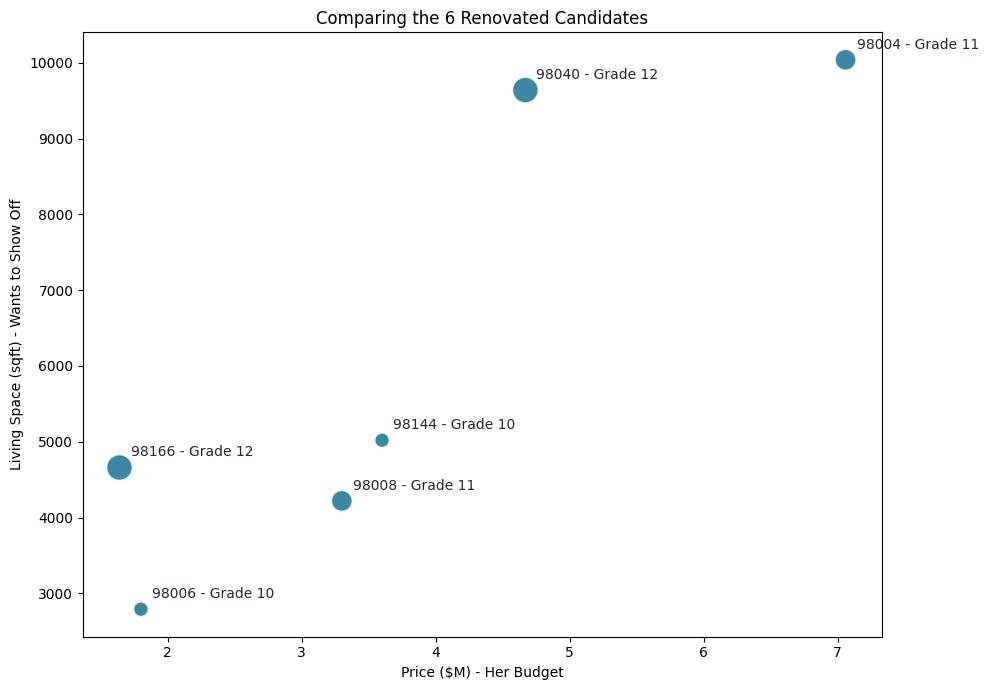

In [320]:
import matplotlib.pyplot as plt

houses = df.loc[mask].copy()

TEAL = '#1C7293'

fig, ax = plt.subplots(figsize=(10, 7))

size_scale = 120  # bubble size = grade
ax.scatter(houses['price'] / 1e6, houses['sqft_living'],
           s=(houses['grade'] - 9) * size_scale,
           color=TEAL, alpha=0.85, edgecolor='white', linewidth=1.5, zorder=2)

for _, row in houses.iterrows():
    label = f"{row['zipcode']} - Grade {row['grade']}"
    ax.annotate(label, (row['price'] / 1e6, row['sqft_living']),
                textcoords="offset points", xytext=(8, 8), fontsize=10,
                color='#1F2933')

ax.set_xlabel('Price ($M) - Her Budget')
ax.set_ylabel('Living Space (sqft) - Wants to Show Off')
ax.set_title('Comparing the 6 Renovated Candidates')
plt.tight_layout()
plt.savefig('renovated_six_compare.png', dpi=150, bbox_inches='tight')
plt.show()

In [321]:
summary = houses[['zipcode', 'price', 'sqft_living', 'grade', 'view', 'condition', 'sqft_living15']].copy()
summary['price'] = (summary['price'] / 1e6).round(2)
summary['bigger_than_neighbors'] = summary['sqft_living'] - summary['sqft_living15']
summary = summary.rename(columns={'price': 'price_$M'})
summary = summary.sort_values('price_$M', ascending=False).reset_index(drop=True)
summary

,zipcode,price_$M,sqft_living,grade,view,condition,sqft_living15,bigger_than_neighbors
0,98004,7.06,10040,11,2.0,3,3930,6110
1,98040,4.67,9640,12,4.0,3,3270,6370
2,98144,3.60,5020,10,4.0,3,3680,1340
3,98008,3.30,4220,11,4.0,4,3810,410
4,98006,1.80,2790,10,4.0,4,3140,-350
5,98166,1.64,4660,12,4.0,3,3140,1520


In [322]:
targets = [
    (98105, 3_650_000),   # Winner
    (98040, 4_670_000),   # Renovated Rival
    (98004, 7_060_000),   # third contender
]

cols = ["id", "zipcode", "price", "grade", "condition", "sqft_living",
        "sqft_living15", "view", "waterfront", "yr_built", "yr_renovated"]

for zc, approx_price in targets:
    match = df[(df["zipcode"] == zc) & (df["price"].between(approx_price - 50_000, approx_price + 50_000))]
    print(f"--- zip {zc} ---")
    print(match[cols].to_string(index=False))
    print()

--- zip 98105 ---
Empty DataFrame
Columns: [id, zipcode, price, grade, condition, sqft_living, sqft_living15, view, waterfront, yr_built, yr_renovated]
Index: []

--- zip 98040 ---
Empty DataFrame
Columns: [id, zipcode, price, grade, condition, sqft_living, sqft_living15, view, waterfront, yr_built, yr_renovated]
Index: []

--- zip 98004 ---
Empty DataFrame
Columns: [id, zipcode, price, grade, condition, sqft_living, sqft_living15, view, waterfront, yr_built, yr_renovated]
Index: []



In [323]:
cols = ["id", "zipcode", "price", "grade", "condition", "sqft_living",
        "sqft_living15", "view", "waterfront", "yr_built", "yr_renovated"]

print("zipcode dtype:", df["zipcode"].dtype)

for zc in [98105, 98040, 98004]:
    match = df[df["zipcode"] == zc]
    print(f"--- zip {zc}: {len(match)} houses ---")
    print(match[cols].sort_values("price", ascending=False).to_string(index=False))
    print()

zipcode dtype: str
--- zip 98105: 0 houses ---
Empty DataFrame
Columns: [id, zipcode, price, grade, condition, sqft_living, sqft_living15, view, waterfront, yr_built, yr_renovated]
Index: []

--- zip 98040: 0 houses ---
Empty DataFrame
Columns: [id, zipcode, price, grade, condition, sqft_living, sqft_living15, view, waterfront, yr_built, yr_renovated]
Index: []

--- zip 98004: 0 houses ---
Empty DataFrame
Columns: [id, zipcode, price, grade, condition, sqft_living, sqft_living15, view, waterfront, yr_built, yr_renovated]
Index: []



In [324]:
cols = ["id", "zipcode", "price", "grade", "condition", "sqft_living",
        "sqft_living15", "view", "waterfront", "yr_built", "yr_renovated"]

print(df["zipcode"].unique()[:5])   # sanity check on the actual string format

for zc in [98105, 98040, 98004]:
    match = df[df["zipcode"].astype(str).str.strip() == str(zc)]
    print(f"--- zip {zc}: {len(match)} houses ---")
    print(match[cols].sort_values("price", ascending=False).to_string(index=False))
    print()

<StringArray>
['98002', '98155', '98188', '98059', '98118']
Length: 5, dtype: str
--- zip 98105: 229 houses ---
        id zipcode     price  grade  condition  sqft_living  sqft_living15  view  waterfront  yr_built  yr_renovated
4217402115   98105 3650000.0     11          5         5480           3510   4.0         1.0      1936           0.0
6613000930   98105 2950000.0     10          5         3890           4140   3.0         1.0      1923           NaN
6613000935   98105 2560000.0     10          2         5300           3890   2.0         1.0      1923           0.0
9471200370   98105 2540000.0     10          5         3710           3970   2.0         0.0      1936           0.0
9471200200   98105 2530000.0     10          3         5040           3960   3.0         0.0      1950           NaN
9471200265   98105 2500000.0     12          3         3960           3960   2.0         0.0      1938           0.0
4218400455   98105 2180000.0     10          3         4710          

In [326]:
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(f"{name}: {obj.shape}")

__: (6, 8)
___: (3, 3)
df: (21420, 26)
zip_stats: (70, 3)
_5: (15, 3)
_6: (2, 3)
corr: (22, 22)
_14: (21420, 23)
jennifer_segment: (57, 26)
_16: (8, 4)
_17: (3, 23)
df_sales: (21597, 4)
resold: (176, 29)
resold_sorted: (353, 5)
resold_changes: (177, 5)
_29: (21420, 23)
_31: (5, 23)
df_sales_raw: (21597, 4)
df_sales_sorted: (21597, 4)
sale_history: (21420, 4)
_35: (5, 6)
_36: (176, 6)
_37: (176, 6)
_38: (5, 24)
_42: (8, 21)
_44: (5, 24)
_50: (1, 24)
missed_waterfront: (164, 26)
missed_view: (1, 26)
jennifer_clean: (46, 36)
_81: (15, 3)
_82: (2, 3)
_90: (21420, 23)
_92: (8, 4)
_93: (3, 23)
_105: (21420, 23)
_107: (5, 23)
_111: (5, 6)
_112: (176, 6)
_113: (176, 6)
_114: (5, 24)
_118: (8, 21)
_120: (5, 24)
_126: (1, 24)
_150: (46, 16)
_151: (740, 26)
_156: (15, 3)
_157: (2, 3)
_165: (21420, 23)
_167: (8, 4)
_168: (3, 23)
_180: (21420, 23)
_182: (5, 23)
_186: (5, 6)
_187: (176, 6)
_188: (176, 6)
_189: (5, 24)
_193: (8, 21)
_195: (5, 24)
_201: (1, 24)
_223: (46, 16)
_224: (740, 26)
_227: (4,

In [327]:
print(resold_changes.columns.tolist())
print(resold_changes.head())

candidate_ids = {
    98105: 4217402115,
    98040: 1924059029,
    98004: 9808700762,
}

for zc, house_id in candidate_ids.items():
    match = resold_changes[resold_changes["id"] == house_id]
    print(f"--- zip {zc}, id {house_id}: {len(match)} match(es) ---")
    print(match.to_string(index=False))
    print()

['date', 'price', 'house_id', 'id', 'pct_change']
             date     price   house_id     id  pct_change
2495   2015-04-22  300000.0    1000102   2496    7.142857
16801  2015-04-24  175000.0    7200179  16802   16.666667
11422  2014-10-20  250000.0  109200390  11423    2.040816
12406  2014-12-08  244900.0  123039336  12407   65.472973
7786   2015-01-14  358000.0  251300110   7787   59.111111
--- zip 98105, id 4217402115: 0 match(es) ---
Empty DataFrame
Columns: [date, price, house_id, id, pct_change]
Index: []

--- zip 98040, id 1924059029: 0 match(es) ---
Empty DataFrame
Columns: [date, price, house_id, id, pct_change]
Index: []

--- zip 98004, id 9808700762: 0 match(es) ---
Empty DataFrame
Columns: [date, price, house_id, id, pct_change]
Index: []



In [328]:
for zc, house_id in candidate_ids.items():
    match = resold_changes[resold_changes["house_id"] == house_id]
    print(f"--- zip {zc}, house_id {house_id}: {len(match)} match(es) ---")
    print(match.to_string(index=False))
    print()

--- zip 98105, house_id 4217402115: 0 match(es) ---
Empty DataFrame
Columns: [date, price, house_id, id, pct_change]
Index: []

--- zip 98040, house_id 1924059029: 0 match(es) ---
Empty DataFrame
Columns: [date, price, house_id, id, pct_change]
Index: []

--- zip 98004, house_id 9808700762: 0 match(es) ---
Empty DataFrame
Columns: [date, price, house_id, id, pct_change]
Index: []



In [330]:
# Pull full house characteristics for the 177 actual repeat sales
resold_full = resold_changes.merge(df, left_on="house_id", right_on="id", how="left")

# Filter for luxury / waterfront comparables among the real repeat sales
luxury_resold = resold_full[(resold_full["waterfront"] == 1) & (resold_full["grade"] >= 10)]
print(f"{len(luxury_resold)} waterfront, high-grade houses among the 177 actual repeat sales")
print(luxury_resold[["house_id", "zipcode", "price_y", "grade", "pct_change"]].to_string(index=False))

0 waterfront, high-grade houses among the 177 actual repeat sales
Empty DataFrame
Columns: [house_id, zipcode, price_y, grade, pct_change]
Index: []


In [331]:
resold_full = resold_changes.merge(df, left_on="house_id", right_on="id", how="left")

price_75 = df["price"].quantile(0.75)
high_value_resold = resold_full[resold_full["price_y"] >= price_75]

print(f"Top price quartile threshold: ${price_75:,.0f}")
print(f"{len(high_value_resold)} houses in the top price quartile among the 177 real repeat sales")
print(f"Median price change: {high_value_resold['pct_change'].median():.1f}%")
print(f"Mean price change: {high_value_resold['pct_change'].mean():.1f}%")
print(high_value_resold[["house_id","zipcode","price_y","grade","pct_change"]].sort_values("price_y", ascending=False).to_string(index=False))

Top price quartile threshold: $645,000
35 houses in the top price quartile among the 177 real repeat sales
Median price change: 20.6%
Mean price change: 37.6%
  house_id zipcode   price_y  grade  pct_change
9809000020   98004 1940000.0      9    2.105263
3528000040   98053 1800000.0     11    6.508876
7856400240   98006 1650000.0     10    1.851852
7856400300   98006 1510000.0     10    7.092199
4139480200   98006 1400000.0     11    1.449275
4139420590   98006 1200000.0     12   -0.826446
5536100020   98004 1190000.0      8   20.567376
5332200530   98112 1020000.0      9   12.087912
3262300940   98039  940000.0      7    7.428571
7409700215   98115  921500.0      7   67.545455
6021500970   98117  874950.0      7  153.608696
7701960990   98077  870000.0     11    0.928074
3271300955   98199  868000.0      9   56.472800
9222400605   98115  850000.0      7    0.890208
5282200015   98115  840000.0      7   60.000000
4139440480   98006  796500.0     10   14.604317
8129700644   98103  78000

In [332]:
house_id = 1924059029
cols = ["id", "zipcode", "lat", "long", "price"]
print(df[df["id"] == house_id][cols].to_string(index=False))

        id zipcode    lat    long     price
1924059029   98040 47.557 -122.21 4670000.0
